# Fantasy Trade Calculator

A dynasty/redraft fantasy football trade calculator that trains supervised gradient-boosting
models to predict market consensus value (FantasyCalc, blended with KeepTradeCut) from player
fundamentals, producing one unified value board per format that puts every player and draft pick
on the same directly-comparable scale.

**Consensus value is the training target, not a benchmark to beat.** These models are trained to
reflect the fantasy trade market as closely as possible -- agreement with FantasyCalc/KeepTradeCut
consensus is the design goal, not an independent finding. Where a player's model-predicted value
diverges from their current market price, that divergence is reported as a residual: a candidate
worth investigating, never a claim that the model is right and the market is wrong.

Full methodology, scope, and known exclusions: see `README.md` in this directory.

**This notebook is fully self-contained** -- every function it uses is defined in a cell below,
organized under the five phases of the **SEMMA** framework (Sample, Explore, Modify, Model,
Assess). There is no separate module to import; run top to bottom.

In [1]:
import datetime
import json
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

import nflreadpy as nfl

load_dotenv()

pd.set_option("display.max_rows", 250)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

Matplotlib is building the font cache; this may take a moment.


## Shared constants & name-matching helper

Used across every phase below (crosswalk joins in Sample, sanity-panel lookups in Assess, etc.),
so defined once, up front.

In [2]:
SEED = 474
KFOLDS = 10

FANTASYCALC_URL = "https://api.fantasycalc.com/values/current"
KTC_DYNASTY_URL = "https://keeptradecut.com/dynasty-rankings"
KTC_REDRAFT_URL = "https://keeptradecut.com/fantasy-rankings"
UA_HEADER = {"User-Agent": "Mozilla/5.0"}

SKILL_POSITIONS = ("QB", "RB", "WR", "TE")

# KTC has no team-size dimension (crowd values are format-only, 1QB vs SF), so its
# signal is treated as a lower-confidence blend-in against FantasyCalc's team-size-aware
# values rather than an equal partner. FantasyCalc also has denser trade-volume data
# backing its market. 0.35 keeps KTC influential on relative ordering without letting it
# override FantasyCalc's format/team-size-specific scale.
BLEND_WEIGHT_KTC = 0.35

SUFFIXES = {"jr", "sr", "ii", "iii", "iv", "v"}

# Common nickname -> formal-first-name pairs, applied to the FIRST token only when
# normalizing names for fallback joins/lookups. Discovered via Kenneth Gainwell (the
# crosswalk's canonical "Kenneth Gainwell" vs FantasyCalc's "Kenny Gainwell") -- the
# ID-based joins for him actually succeed fine (mfl_id/espn_id/ktc_id all agree
# across sources), so this wasn't a crosswalk-join bug; it was the sanity panel's own
# name lookup doing an exact string match with no normalization at all. Generalized
# here since the same nickname/formal-name mismatch class can affect any name-based
# lookup or fallback join, not just this one player.
NICKNAME_TO_FORMAL = {
    "kenny": "kenneth", "josh": "joshua", "mike": "michael", "chris": "christopher",
    "nick": "nicholas", "matt": "matthew", "dave": "david", "rob": "robert",
    "will": "william", "tony": "anthony", "sam": "samuel", "joe": "joseph",
    "dan": "daniel", "steve": "steven", "andy": "andrew", "tom": "thomas",
    "jim": "james", "alex": "alexander",
}


def normalize_name(name: str) -> str:
    """Lowercase, strip punctuation and generational suffixes, canonicalize common
    nickname/formal-first-name pairs, for last-resort name joins and name-based
    lookups.
    """
    if not isinstance(name, str):
        return ""
    cleaned = re.sub(r"[^a-z0-9\s]", "", name.lower())
    tokens = [t for t in cleaned.split() if t not in SUFFIXES]
    if tokens:
        tokens[0] = NICKNAME_TO_FORMAL.get(tokens[0], tokens[0])
    return " ".join(tokens)

In [3]:
CURRENT_SEASON = 2026  # the season these valuations are for; also gates the draft_capital gsis_id repair below

## Table of contents -- SEMMA

- **[Sample](#Phase-1:-Sample)** -- pull every raw data source (FantasyCalc, KeepTradeCut,
  nflreadpy, CollegeFootballData) and join it to one canonical player identity via the crosswalk.
  Nothing here transforms or engineers features, it only fetches and identifies.
- **[Explore](#Phase-2:-Explore)** -- inspect what Sample produced before transforming any of it:
  target distributions, feature missingness, feature-vs-target correlation, and the raw
  age-vs-production relationship. Read-only diagnostics, no feature engineering.
- **[Modify](#Phase-3:-Modify)** -- transform the sampled data into the feature table and target
  values actually fit on: the aging-curve features, the unified per-player snapshot, and
  fundamentals-based valuation of the pick-asset class.
- **[Model](#Phase-4:-Model)** -- fit the sample-weighted gradient-boosting models (plus a
  RandomForest baseline and a rookie risk-discount model) that predict consensus value from the
  Modify-phase feature table.
- **[Assess](#Phase-5:-Assess)** -- turn predictions into the final boards, quantify
  model-vs-market divergence, sanity-check the result against real-world knowledge, and support
  in-season refresh.

## Phase 1: Sample

Acquire raw data from every source and join it to one canonical player identity (the ID
crosswalk). Nothing in this phase transforms or engineers features -- it only fetches and
identifies.

### 1.1 -- ID crosswalk

In [4]:
def build_crosswalk() -> pd.DataFrame:
    """Master ID crosswalk from nflreadpy's dynastyprocess-sourced player-id table.

    Covers mfl_id (100% populated -- FantasyCalc's own primary key), espn_id
    (FantasyCalc secondary key), ktc_id (KeepTradeCut's own player id, matches KTC's
    `playerID` field directly -- verified empirically at 100% on the top-200 pool),
    gsis_id (nflreadpy weekly-stats key), and pfr_id (matches load_snap_counts'
    `pfr_player_id` and load_combine's `pfr_id` -- both use the same PFR id scheme,
    e.g. "BrowSp00", verified empirically) for the feature-assembly stage.
    """
    cw = nfl.load_ff_playerids().to_pandas()
    cw = cw[["mfl_id", "sleeper_id", "espn_id", "gsis_id", "ktc_id", "pfr_id", "name", "position"]].copy()
    cw["mfl_id"] = pd.to_numeric(cw["mfl_id"], errors="coerce")
    cw["espn_id"] = pd.to_numeric(cw["espn_id"], errors="coerce")
    cw["ktc_id"] = pd.to_numeric(cw["ktc_id"], errors="coerce")
    cw["merge_name"] = cw["name"].apply(normalize_name)
    assert cw["mfl_id"].notna().all(), "mfl_id should be fully populated by source"
    dup_mfl = cw["mfl_id"].duplicated().sum()
    assert dup_mfl == 0, f"crosswalk has {dup_mfl} duplicate mfl_id rows"
    return cw

In [5]:
crosswalk = build_crosswalk()
print(f"crosswalk rows: {len(crosswalk)}")

crosswalk rows: 12472


### 1.2 -- Pull FantasyCalc (6 format-teamsize combos) and KeepTradeCut (dynasty + redraft)

In [6]:
FORMATS = {
    # name -> (is_dynasty, num_qbs)
    "sf_dynasty": (True, 2),
    "oneqb_dynasty": (True, 1),
    "redraft": (False, 1),
}
TEAM_SIZES = (10, 12)


def pull_fantasycalc(is_dynasty: bool, num_qbs: int, num_teams: int) -> pd.DataFrame:
    params = {
        "isDynasty": str(is_dynasty).lower(),
        "numQbs": num_qbs,
        "numTeams": num_teams,
        "ppr": 1,
    }
    resp = requests.get(FANTASYCALC_URL, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    rows = []
    for d in data:
        p = d["player"]
        rows.append({
            "name": p["name"],
            "position": p["position"],
            "mflId": p.get("mflId"),
            "sleeperId": p.get("sleeperId"),
            "espnId": p.get("espnId"),
            "value": d["value"],
            "overallRank": d.get("overallRank"),
        })
    df = pd.DataFrame(rows)
    df["mflId"] = pd.to_numeric(df["mflId"], errors="coerce")
    df["espnId"] = pd.to_numeric(df["espnId"], errors="coerce")
    assert df["name"].notna().all()
    skill_mfl = df.loc[df["position"] != "PICK", "mflId"].dropna()
    dup = skill_mfl.duplicated().sum()
    assert dup == 0, f"FantasyCalc pull has {dup} duplicate player mflId rows: " \
        f"{skill_mfl[skill_mfl.duplicated(keep=False)].tolist()}"
    return df


def pull_all_fantasycalc() -> dict:
    """Returns {(format_name, num_teams): DataFrame} for all 6 format x team-size combos."""
    out = {}
    for fmt_name, (is_dynasty, num_qbs) in FORMATS.items():
        for num_teams in TEAM_SIZES:
            out[(fmt_name, num_teams)] = pull_fantasycalc(is_dynasty, num_qbs, num_teams)
    return out

In [7]:
def _extract_players_array(html: str) -> list:
    m = re.search(r"playersArray\s*=\s*(\[.*?\]);", html, re.DOTALL)
    if not m:
        raise ValueError("playersArray not found in KTC page -- page structure may have changed")
    return json.loads(m.group(1))


def pull_ktc_dynasty() -> pd.DataFrame:
    """KTC dynasty-rankings page. One payload carries both oneQB and superflex values
    per player (KTC has no team-size dimension), plus RDP (rookie draft pick) rows
    with Early/Mid/Late tiers across multiple future years, preserved raw for the
    pick-valuation stage.
    """
    resp = requests.get(KTC_DYNASTY_URL, headers=UA_HEADER, timeout=30)
    resp.raise_for_status()
    data = _extract_players_array(resp.text)
    rows = []
    for d in data:
        rows.append({
            "name": d["playerName"],
            "position": d["position"],
            "playerID": d["playerID"],
            "oneqb_value": d["oneQBValues"]["value"],
            "sf_value": d["superflexValues"]["value"],
        })
    df = pd.DataFrame(rows)
    dup = df[df["position"].isin(SKILL_POSITIONS)]["playerID"].duplicated().sum()
    assert dup == 0, f"KTC dynasty pull has {dup} duplicate skill-player playerID rows"
    return df


def pull_ktc_redraft() -> pd.DataFrame:
    """KTC fantasy-rankings (redraft) page. Structure differs from the dynasty page:
    framed as start/sit rankings (`startSitValue`) but each player object also carries
    a plain season-long `value` under oneQBValues/superflexValues, same shape as the
    dynasty payload, which is what we use here for consistency with the dynasty pull.
    No RDP rows on this page -- redraft has no draft-pick assets, matches spec §6.
    K/DST rows are present and filtered out (out of scope, matches spec §2).
    """
    resp = requests.get(KTC_REDRAFT_URL, headers=UA_HEADER, timeout=30)
    resp.raise_for_status()
    data = _extract_players_array(resp.text)
    rows = []
    for d in data:
        if d["position"] not in SKILL_POSITIONS:
            continue
        rows.append({
            "name": d["playerName"],
            "position": d["position"],
            "playerID": d["playerID"],
            "oneqb_value": d["oneQBValues"]["value"],
            "sf_value": d["superflexValues"]["value"],
        })
    df = pd.DataFrame(rows)
    dup = df["playerID"].duplicated().sum()
    assert dup == 0, f"KTC redraft pull has {dup} duplicate playerID rows"
    return df

In [8]:
fc_all = pull_all_fantasycalc()
for k, v in fc_all.items():
    print(f"  {k}: {len(v)} rows")

ktc_dyn = pull_ktc_dynasty()
ktc_redraft = pull_ktc_redraft()
print(f"ktc_dynasty: {len(ktc_dyn)} rows, ktc_redraft: {len(ktc_redraft)} rows")

  ('sf_dynasty', 10): 475 rows
  ('sf_dynasty', 12): 475 rows
  ('oneqb_dynasty', 10): 475 rows
  ('oneqb_dynasty', 12): 475 rows
  ('redraft', 10): 171 rows
  ('redraft', 12): 171 rows


ktc_dynasty: 500 rows, ktc_redraft: 300 rows


### 1.3 -- Crosswalk joins

In [9]:
def _log_unmatched(label: str, unmatched_names: list):
    if unmatched_names:
        print(f"[{label}] {len(unmatched_names)} unmatched after fallback: {unmatched_names[:25]}"
              + (" ..." if len(unmatched_names) > 25 else ""))


def join_fantasycalc_crosswalk(fc_df: pd.DataFrame, crosswalk: pd.DataFrame, label: str = "FC") -> pd.DataFrame:
    """Join on mflId (FantasyCalc's own primary id, 100% populated in crosswalk).
    espnId as secondary for rows mflId misses; normalized-name as documented last resort.
    Each row ends up with exactly one crosswalk match, filled in priority order via
    combine_first (mflId > espnId > normalized-name), so there's no positional-index
    bookkeeping between separate merge passes.
    """
    skill = fc_df[fc_df["position"].isin(SKILL_POSITIONS)].reset_index(drop=True).copy()
    skill["merge_name_src"] = skill["name"].apply(normalize_name)

    cw_cols = ["mfl_id", "espn_id", "gsis_id", "ktc_id"]

    by_mfl = skill.merge(crosswalk.drop_duplicates("mfl_id")[["mfl_id"] + cw_cols[1:]],
                          left_on="mflId", right_on="mfl_id", how="left")[cw_cols]
    by_espn = skill.merge(crosswalk.dropna(subset=["espn_id"]).drop_duplicates("espn_id")[["espn_id"] + [c for c in cw_cols if c != "espn_id"]],
                           left_on="espnId", right_on="espn_id", how="left")[cw_cols]
    by_name = skill.merge(crosswalk.drop_duplicates("merge_name")[["merge_name"] + cw_cols],
                           left_on="merge_name_src", right_on="merge_name", how="left")[cw_cols]

    resolved = by_mfl.combine_first(by_espn)
    n_espn_only = (by_mfl["mfl_id"].isna() & by_espn["mfl_id"].notna()).sum()
    if n_espn_only:
        print(f"[{label}] {n_espn_only} rows matched via espnId fallback (not mflId)")

    still_missing = resolved["mfl_id"].isna()
    n_name_only = (still_missing & by_name["mfl_id"].notna()).sum()
    resolved = resolved.combine_first(by_name)
    if n_name_only:
        print(f"[{label}] {n_name_only} rows matched via normalized-name fallback (documented last resort)")

    merged = pd.concat([skill, resolved], axis=1)
    unmatched = merged.loc[merged["mfl_id"].isna(), "name"].tolist()
    _log_unmatched(label, unmatched)

    cw = crosswalk.drop_duplicates("mfl_id")
    top200 = skill.nlargest(200, "value")
    top200_matched = top200["mflId"].isin(cw["mfl_id"]).mean()
    print(f"[{label}] top-200 join coverage: {top200_matched:.1%}")
    assert top200_matched >= 0.95, f"{label} crosswalk join coverage {top200_matched:.1%} below 95% threshold"

    return merged


def bridge_ktc_redraft_ids(ktc_redraft_df: pd.DataFrame, ktc_dyn_df: pd.DataFrame) -> pd.DataFrame:
    """KTC's redraft (fantasy-rankings) page and dynasty-rankings page use DIFFERENT
    internal `playerID` numbering for the same player -- discovered empirically (e.g.
    Bijan Robinson is playerID 1414 on the dynasty page, 1507 on the redraft page;
    established veterans like Ja'Marr Chase/Josh Allen/Justin Jefferson happen to share
    the same id on both pages, but most players added more recently don't). The
    crosswalk's `ktc_id` column matches the DYNASTY page's numbering (verified at 100%
    on the top-200 pool), not the redraft page's, which is why joining redraft rows to
    the crosswalk directly on raw `playerID` only hit 43% coverage.

    Fix: bridge redraft rows to the dynasty page's playerID via normalized-name match
    (93.7% match rate empirically) BEFORE the crosswalk join, so join_ktc_crosswalk can
    use its normal ktc_id path for the bridged majority; the ~6% that don't bridge by
    name still fall through to join_ktc_crosswalk's own documented name-fallback.
    """
    dyn_skill = ktc_dyn_df[ktc_dyn_df["position"].isin(SKILL_POSITIONS)].copy()
    dyn_skill["merge_name"] = dyn_skill["name"].apply(normalize_name)
    dyn_lookup = dyn_skill.drop_duplicates("merge_name").set_index("merge_name")["playerID"]

    out = ktc_redraft_df.copy()
    out["merge_name"] = out["name"].apply(normalize_name)
    bridged = out["merge_name"].map(dyn_lookup)
    n_bridged = bridged.notna().sum()
    out["playerID"] = bridged.combine_first(out["playerID"])
    print(f"[ktc_redraft_bridge] {n_bridged}/{len(out)} rows bridged to dynasty-page playerID by name "
          f"({n_bridged / len(out):.1%})")
    return out.drop(columns=["merge_name"])


def join_ktc_crosswalk(ktc_df: pd.DataFrame, crosswalk: pd.DataFrame, label: str = "KTC") -> pd.DataFrame:
    """Join on ktc_id (KTC's own playerID, verified to match nflreadpy's ktc_id column
    at 100% on the top-200 pool). Normalized-name as documented last resort.
    """
    skill = ktc_df[ktc_df["position"].isin(SKILL_POSITIONS)].reset_index(drop=True).copy()
    skill["merge_name_src"] = skill["name"].apply(normalize_name)

    cw_cols = ["ktc_id", "mfl_id", "gsis_id", "espn_id"]
    cw_ktc = crosswalk.dropna(subset=["ktc_id"]).drop_duplicates("ktc_id")
    cw_name = crosswalk.drop_duplicates("merge_name")

    by_ktc = skill.merge(cw_ktc[cw_cols], left_on="playerID", right_on="ktc_id", how="left")[cw_cols]
    by_name = skill.merge(cw_name[["merge_name"] + cw_cols], left_on="merge_name_src", right_on="merge_name",
                           how="left")[cw_cols]

    still_missing = by_ktc["ktc_id"].isna()
    n_name_only = (still_missing & by_name["ktc_id"].notna()).sum()
    resolved = by_ktc.combine_first(by_name)
    if n_name_only:
        print(f"[{label}] {n_name_only} rows matched via normalized-name fallback (documented last resort)")

    merged = pd.concat([skill, resolved], axis=1)
    unmatched = merged.loc[merged["ktc_id"].isna(), "name"].tolist()
    _log_unmatched(label, unmatched)

    value_col = "sf_value" if "sf_value" in skill.columns else "value"
    top200 = skill.nlargest(200, value_col)
    top200_matched = top200["playerID"].isin(cw_ktc["ktc_id"]).mean()
    print(f"[{label}] top-200 join coverage: {top200_matched:.1%}")
    assert top200_matched >= 0.95, f"{label} crosswalk join coverage {top200_matched:.1%} below 95% threshold"

    return merged

#### Blend example -- SF dynasty, 12 team

In [10]:
def blend_consensus(fc_joined: pd.DataFrame, ktc_joined: pd.DataFrame, ktc_value_col: str,
                     blend_weight_ktc: float = BLEND_WEIGHT_KTC) -> pd.DataFrame:
    """Percentile-rank each source within its own pool, blend the percentiles, then
    re-project the blended percentile onto FantasyCalc's native value distribution --
    the one value scale that's genuinely team-size/format calibrated. KTC only ever
    shifts relative ordering within that scale; it never introduces its own units.
    """
    fc = fc_joined.dropna(subset=["mfl_id"]).copy()
    fc["fc_percentile"] = fc["value"].rank(pct=True) * 100

    ktc = ktc_joined.dropna(subset=["ktc_id"]).copy()
    ktc["ktc_percentile"] = ktc[ktc_value_col].rank(pct=True) * 100

    merged = fc.merge(
        ktc[["mfl_id", "ktc_percentile"]] if "mfl_id" in ktc.columns else ktc[["gsis_id", "ktc_percentile"]],
        on=[c for c in ("mfl_id",) if c in ktc.columns] or ["gsis_id"],
        how="left",
    )
    # players FantasyCalc prices but KTC doesn't (deep bench) fall back to FC-only percentile
    merged["ktc_percentile"] = merged["ktc_percentile"].fillna(merged["fc_percentile"])
    merged["blended_percentile"] = (
        blend_weight_ktc * merged["ktc_percentile"] + (1 - blend_weight_ktc) * merged["fc_percentile"]
    )
    pct = (merged["blended_percentile"] / 100.0).clip(0, 1)
    merged["consensus_value"] = np.quantile(fc["value"], pct)
    return merged

In [11]:
fc_joined_demo = join_fantasycalc_crosswalk(fc_all[("sf_dynasty", 12)], crosswalk, label="FC-SF12")
ktc_joined_demo = join_ktc_crosswalk(ktc_dyn, crosswalk, label="KTC-dyn")
blended_demo = blend_consensus(fc_joined_demo, ktc_joined_demo, ktc_value_col="sf_value")
blended_demo[["name", "position", "value", "ktc_percentile", "fc_percentile", "consensus_value"]] \
    .sort_values("consensus_value", ascending=False).head(15)

[FC-SF12] 2 rows matched via normalized-name fallback (documented last resort)
[FC-SF12] top-200 join coverage: 100.0%
[KTC-dyn] 7 unmatched after fallback: ['Hassan Haskins', 'Stetson Bennett', 'Dylan Laube', 'Thomas Fidone', 'Sterling Shepard', 'Foster Moreau', 'Tim Patrick']
[KTC-dyn] top-200 join coverage: 100.0%


,name,position,value,ktc_percentile,fc_percentile,consensus_value
0,Bijan Robinson,RB,10438,100.000000,100.000000,10438.000000
1,Josh Allen,QB,10225,99.452954,99.749373,10210.225386
2,Jahmyr Gibbs,RB,10189,99.781182,99.498747,10203.343989
3,Ja'Marr Chase,WR,10080,99.452954,99.248120,10111.920891
4,Jaxon Smith-Njigba,WR,8777,99.124726,98.997494,9021.000136
5,Drake Maye,QB,8595,98.905908,98.746867,8637.601712
6,Puka Nacua,WR,8308,98.687090,98.496241,8388.615548
7,Brock Bowers,TE,7606,98.468271,98.245614,7836.049246
9,Amon-Ra St. Brown,WR,7264,98.249453,97.744361,7287.962937
8,Lamar Jackson,QB,7297,97.592998,97.994987,7279.182592


### 1.4 -- Historical production, snap share, draft capital

In [12]:
HIST_START_YEAR = 2019
HIST_END_YEAR = 2025

CFBD_BASE = "https://api.collegefootballdata.com"


def load_weekly_features(start_year: int = HIST_START_YEAR, end_year: int = HIST_END_YEAR) -> pd.DataFrame:
    """Season-level production + efficiency per player-season, QB/RB/WR/TE only.

    `load_player_stats(summary_level="reg")` already returns one row per player per
    season (verified empirically: 0 duplicate player_id+season rows for skill
    positions) -- no manual weekly aggregation needed. Snap share is joined in
    separately since load_snap_counts is weekly/team-level and keyed on
    pfr_player_id, not player_id.
    """
    seasons = list(range(start_year, end_year + 1))
    stats = nfl.load_player_stats(seasons=seasons, summary_level="reg").to_pandas()
    stats = stats[stats["position"].isin(SKILL_POSITIONS)].copy()
    dup = stats.duplicated(subset=["player_id", "season"]).sum()
    assert dup == 0, f"load_player_stats has {dup} duplicate player_id+season rows"

    keep_cols = [
        "player_id", "player_display_name", "position", "season", "games",
        "completions", "attempts", "passing_yards", "passing_tds", "passing_epa", "passing_cpoe",
        "carries", "rushing_yards", "rushing_tds", "rushing_epa",
        "targets", "receptions", "receiving_yards", "receiving_tds", "receiving_epa",
        "target_share", "air_yards_share", "wopr", "racr",
        "fantasy_points_ppr",
    ]
    weekly = stats[keep_cols].rename(columns={"player_id": "gsis_id"})
    weekly["ppg_ppr"] = weekly["fantasy_points_ppr"] / weekly["games"].replace(0, np.nan)

    snap_share = _load_season_snap_share(start_year, end_year)
    before = len(weekly)
    weekly = weekly.merge(snap_share, on=["gsis_id", "season"], how="left")
    assert len(weekly) == before, "snap-share merge changed row count -- duplicate keys on snap_share side"
    dup2 = weekly.duplicated(subset=["gsis_id", "season"]).sum()
    assert dup2 == 0, f"weekly features has {dup2} duplicate gsis_id+season rows after snap merge"
    return weekly


def _load_season_snap_share(start_year: int, end_year: int) -> pd.DataFrame:
    """Mean offense_pct per player-season, joined to gsis_id via
    pfr_player_id -> crosswalk.pfr_id (same PFR id scheme, verified empirically).
    """
    seasons = list(range(start_year, end_year + 1))
    snaps = nfl.load_snap_counts(seasons=seasons).to_pandas()
    snaps = snaps[snaps["position"].isin(SKILL_POSITIONS)]
    season_snap = (
        snaps.groupby(["pfr_player_id", "season"], as_index=False)["offense_pct"].mean()
        .rename(columns={"offense_pct": "snap_share"})
    )
    cw_pfr = build_crosswalk().dropna(subset=["pfr_id"]).drop_duplicates("pfr_id")[["pfr_id", "gsis_id"]]
    merged = season_snap.merge(cw_pfr, left_on="pfr_player_id", right_on="pfr_id", how="left")
    unmatched = merged["gsis_id"].isna().mean()
    print(f"[snap_share] {unmatched:.1%} of player-season snap rows unmatched to gsis_id via pfr_id (dropped)")
    merged = merged.dropna(subset=["gsis_id"])[["gsis_id", "season", "snap_share"]]
    dup = merged.duplicated(subset=["gsis_id", "season"]).sum()
    assert dup == 0, f"snap_share has {dup} duplicate gsis_id+season rows"
    return merged

In [13]:
_VALID_GSIS_RE = re.compile(r"^\d{2}-\d{7}$")


def load_draft_capital(crosswalk: pd.DataFrame | None = None) -> pd.DataFrame:
    """Draft capital directly from load_draft_picks -- it carries gsis_id, round,
    pick, age (age at the draft event), and college natively for players with real
    NFL history.

    BUT for the most recent draft class (players with zero NFL games played, so no
    real gsis_id has ever been assigned by the league's own game-log system),
    load_draft_picks' `gsis_id` column is NOT a real gsis_id -- it's some other
    internal identifier in a completely different format (verified empirically, e.g.
    Fernando Mendoza shows `MEN516487` here vs. the correct `00-0041562` that
    FantasyCalc's own mfl_id resolves to via the crosswalk). A real gsis_id always
    matches `\\d{2}-\\d{7}` (e.g. "00-0041562"); anything else gets re-resolved by
    normalized-name lookup against `crosswalk` when one is passed in (documented
    fallback, every unresolved name logged, never silently dropped or left wrong).
    Passing no crosswalk skips this repair (only used by tests that don't need it).
    """
    dp = nfl.load_draft_picks(seasons=True).to_pandas()
    dp = dp[dp["position"].isin(SKILL_POSITIONS)].copy()
    dp = dp.dropna(subset=["gsis_id"])
    dup = dp["gsis_id"].duplicated().sum()
    if dup:
        print(f"[draft_capital] {dup} duplicate gsis_id rows in load_draft_picks -- "
              f"keeping first (data-entry dupes, e.g. supplemental draft)")
        dp = dp.drop_duplicates(subset=["gsis_id"], keep="first")
    out = dp[["gsis_id", "season", "round", "pick", "age", "college", "position", "pfr_player_name"]].rename(
        columns={"season": "draft_year", "pfr_player_name": "draft_name", "age": "age_at_draft"}
    )

    if crosswalk is not None:
        # Scoped to CURRENT_SEASON only: load_draft_picks' gsis_id is unreliable for
        # historical decades-old picks too (verified -- 646 rows total have a non-
        # standard id, going back to the 1980s), but those seasons never touch this
        # pipeline (weekly features only cover HIST_START_YEAR+ and they're all long
        # retired), and attempting to repair them by name risks colliding with an
        # unrelated modern player who shares a common name -- exactly what caused a
        # handful of real duplicate-gsis_id collisions when this was first tried
        # unscoped. Only CURRENT_SEASON's zero-snap class actually needs repair here.
        bad_mask = (~out["gsis_id"].str.match(_VALID_GSIS_RE)) & (out["draft_year"] == CURRENT_SEASON)
        n_bad = int(bad_mask.sum())
        if n_bad:
            cw = crosswalk.copy()
            cw["merge_name"] = cw["name"].apply(normalize_name)
            cw_lookup = cw.dropna(subset=["gsis_id"]).drop_duplicates("merge_name").set_index("merge_name")["gsis_id"]
            fixed_name = out.loc[bad_mask, "draft_name"].apply(normalize_name)
            resolved = fixed_name.map(cw_lookup)
            n_resolved = resolved.notna().sum()
            out.loc[bad_mask, "gsis_id"] = resolved.combine_first(out.loc[bad_mask, "gsis_id"])
            still_bad = out.loc[bad_mask, "gsis_id"][~out.loc[bad_mask, "gsis_id"].str.match(_VALID_GSIS_RE)]
            print(f"[draft_capital] {n_bad} rows had a non-gsis id from load_draft_picks (new/unplayed draft "
                  f"class) -- {n_resolved}/{n_bad} repaired via crosswalk name match")
            if len(still_bad):
                print(f"[draft_capital] {len(still_bad)} rows still unresolved after repair attempt: "
                      f"{out.loc[still_bad.index, 'draft_name'].tolist()}")
            dup2 = out["gsis_id"].duplicated().sum()
            assert dup2 == 0, f"draft_capital has {dup2} duplicate gsis_id rows after id repair"
    return out

In [14]:
draft_capital = load_draft_capital(crosswalk)
print(f"draft_capital rows: {len(draft_capital)}")

weekly = load_weekly_features()
print(f"weekly features rows: {len(weekly)}, cols: {len(weekly.columns)}")

[draft_capital] 2 duplicate gsis_id rows in load_draft_picks -- keeping first (data-entry dupes, e.g. supplemental draft)
[draft_capital] 73 rows had a non-gsis id from load_draft_picks (new/unplayed draft class) -- 73/73 repaired via crosswalk name match
[draft_capital] 1 rows still unresolved after repair attempt: ['Mike Washington Jr.']
draft_capital rows: 3551


[snap_share] 1.0% of player-season snap rows unmatched to gsis_id via pfr_id (dropped)
weekly features rows: 4191, cols: 27


### 1.5 -- Combine metrics

In [15]:
def load_combine_features() -> pd.DataFrame:
    """RB speed score (weight-adjusted 40 time): speed_score = (weight_lbs * 200) /
    (forty_time ** 4) -- the standard public-analysis formula (Bill Barnwell / Zoltan
    Buday). Joined to gsis_id via pfr_id primarily (load_combine's `pfr_id` matches
    crosswalk's `pfr_id`, same PFR scheme verified for snap counts above), with a
    normalized-name fallback -- the same combine_first priority-join pattern already
    used for FantasyCalc/KTC in join_fantasycalc_crosswalk/join_ktc_crosswalk -- since
    pfr_id alone only covers ~65% of combine rows on its own (this gap concretely
    caused a sanity-panel failure: Josh Jacobs' speed_score came back NaN because his
    combine row didn't match via pfr_id).
    """
    combine = nfl.load_combine(seasons=True).to_pandas()
    combine = combine[combine["pos"].isin(SKILL_POSITIONS)].reset_index(drop=True).copy()
    combine["merge_name_src"] = combine["player_name"].apply(normalize_name)

    crosswalk = build_crosswalk()
    cw_pfr = crosswalk.dropna(subset=["pfr_id"]).drop_duplicates("pfr_id")[["pfr_id", "gsis_id"]]
    cw_name = crosswalk.drop_duplicates("merge_name")[["merge_name", "gsis_id"]]

    by_pfr = combine.merge(cw_pfr, on="pfr_id", how="left")["gsis_id"]
    by_name = combine.merge(cw_name, left_on="merge_name_src", right_on="merge_name", how="left")["gsis_id"]

    before_coverage = by_pfr.notna().mean()
    n_name_only = (by_pfr.isna() & by_name.notna()).sum()
    resolved = by_pfr.combine_first(by_name)
    after_coverage = resolved.notna().mean()
    print(f"[combine] gsis_id coverage: {before_coverage:.1%} (pfr_id only) -> {after_coverage:.1%} "
          f"after normalized-name fallback ({n_name_only} rows recovered)")

    merged = combine.copy()
    merged["gsis_id"] = resolved
    merged = merged.dropna(subset=["gsis_id"])
    dup = merged["gsis_id"].duplicated().sum()
    if dup:
        merged = merged.sort_values("draft_year").drop_duplicates(subset=["gsis_id"], keep="last")
    merged["speed_score"] = np.where(
        (merged["pos"] == "RB") & merged["wt"].notna() & merged["forty"].notna() & (merged["forty"] > 0),
        (merged["wt"] * 200) / (merged["forty"] ** 4),
        np.nan,
    )
    out = merged[["gsis_id", "forty", "wt", "ht", "speed_score"]].rename(
        columns={"wt": "combine_weight", "ht": "combine_height", "forty": "forty_time"}
    )
    return out

In [16]:
combine_feats = load_combine_features()
print(f"combine feature rows: {len(combine_feats)}")
combine_feats.dropna(subset=["speed_score"]).head(3)

[combine] gsis_id coverage: 64.9% (pfr_id only) -> 70.2% after normalized-name fallback (160 rows recovered)
combine feature rows: 2103


,gsis_id,forty_time,combine_weight,combine_height,speed_score
56,00-0019641,4.45,216.0,5-10,110.165016
125,00-0020270,4.53,226.0,6-0,107.336054
118,00-0020514,4.38,207.0,5-9,112.487405


### 1.6 -- Rookie college production (CollegeFootballData)

In [17]:
def _cfbd_headers() -> dict:
    key = os.environ.get("CFBD_API_KEY")
    assert key, "CFBD_API_KEY not set -- add it to .env (see README), never hardcode it in source"
    return {"Authorization": f"Bearer {key}"}


class CFBDQuotaExceeded(Exception):
    """Raised specifically when CFBD's free-tier monthly call quota is exhausted
    (HTTP 429 with 'quota' in the response body) -- an expected, documented
    free-tier limit, not a bug. Kept as its own exception type (not a
    requests.RequestException subclass) so callers can count and report
    quota-exhaustion separately from genuine request failures (network errors,
    malformed requests, auth problems) instead of lumping every CFBD failure into
    one silent 'no data' outcome, which made the two situations indistinguishable.
    """


def _cfbd_get(url: str, params: dict):
    """GET wrapper for every CFBD endpoint call in this module. Raises
    CFBDQuotaExceeded for a quota-exhausted 429; any other non-2xx response raises
    the normal requests.HTTPError via raise_for_status (a real failure worth
    investigating, not the quota).
    """
    r = requests.get(url, params=params, headers=_cfbd_headers(), timeout=30)
    if r.status_code == 429 and "quota" in r.text.lower():
        raise CFBDQuotaExceeded(r.text)
    r.raise_for_status()
    return r.json()


def cfbd_player_search(name: str) -> list:
    return _cfbd_get(f"{CFBD_BASE}/player/search", {"searchTerm": name})


_team_totals_cache: dict = {}


def _cfbd_team_totals(year: int, team: str) -> tuple:
    """(net_passing_yards, passing_tds) as a proxy for team receiving totals -- CFBD's
    team-season endpoint has no direct 'receiving' category; net passing yards and
    passing TDs are the closest available proxy (receptions ~= completions; the only
    gap is sack yardage, immaterial for a share calculation). Cached per (year, team)
    since many rookies share a team.
    """
    key = (year, team)
    if key in _team_totals_cache:
        return _team_totals_cache[key]
    data_list = _cfbd_get(f"{CFBD_BASE}/stats/season", {"year": year, "team": team})
    data = {d["statName"]: d["statValue"] for d in data_list}
    result = (data.get("netPassingYards"), data.get("passingTDs"))
    _team_totals_cache[key] = result
    return result


_receiving_season_cache: dict = {}


def _cfbd_player_receiving_season(year: int, team: str) -> pd.DataFrame:
    """Whole-roster receiving stats for one (year, team) -- cached, since many rookies
    in the same draft class share a college team/year and would otherwise trigger
    duplicate identical API calls.
    """
    key = (year, team)
    if key in _receiving_season_cache:
        return _receiving_season_cache[key]
    data = _cfbd_get(f"{CFBD_BASE}/stats/player/season", {"year": year, "team": team, "category": "receiving"})
    if not data:
        result = pd.DataFrame(columns=["player", "YDS", "TD"])
    else:
        df = pd.DataFrame(data)
        result = df.pivot_table(index="player", columns="statType", values="stat", aggfunc="first").reset_index()
    _receiving_season_cache[key] = result
    return result


def compute_rookie_college_features(draft_capital_df: pd.DataFrame, draft_year: int = 2026) -> pd.DataFrame:
    """Rookie college-production prior features for a given zero-NFL-snap draft class
    (default 2026). Computes dominator rating (80% yardage / 20% TD weighted share of
    team receiving output, per spec §5's exact weighting) and breakout age (age at the
    earliest college season where dominator rating >= 20%) for WR/TE/RB. QBs get no
    college dominator -- the spec doesn't define one for passers -- and rely on draft
    capital + age alone, consistent with spec §5 framing draft capital as the single
    best predictor on its own.

    YPRR (yards per route run), called out in spec §5 as part of the WR "core
    predictive triad", was investigated and confirmed NOT available anywhere in CFBD's
    free tier (checked /stats/player/season and /ppa/players/season -- no
    route-participation data exists). It is dropped rather than approximated; the
    rookie prior runs on draft capital + dominator rating + breakout age + age-at-draft
    (+ RB speed score from combine) instead.
    """
    rookies = draft_capital_df[draft_capital_df["draft_year"] == draft_year].copy()
    rows = []
    n_quota_exhausted = 0
    n_other_failure = 0
    for _, r in rookies.iterrows():
        name, pos, college = r["draft_name"], r["position"], r["college"]
        quota_hit = False
        other_hit = False
        try:
            hits = cfbd_player_search(name)
        except CFBDQuotaExceeded:
            hits = []
            quota_hit = True
        except requests.RequestException:
            hits = []
            other_hit = True
        hit = next((h for h in hits if h.get("team") == college), hits[0] if hits else None)

        if hit is None or pos == "QB" or hit.get("activeStartYear") is None:
            if quota_hit:
                n_quota_exhausted += 1
            elif other_hit:
                n_other_failure += 1
            rows.append({"gsis_id": r["gsis_id"], "dominator_rating": np.nan, "breakout_age": np.nan,
                         "college_seasons_found": 0})
            continue

        start_yr = int(hit["activeStartYear"])
        end_yr = min(int(hit.get("activeEndYear") or (draft_year - 1)), draft_year - 1)
        team = hit["team"]

        season_dominators = {}
        for yr in range(start_yr, end_yr + 1):
            try:
                rec = _cfbd_player_receiving_season(yr, team)
                net_pass_yds, pass_tds = _cfbd_team_totals(yr, team)
            except CFBDQuotaExceeded:
                quota_hit = True
                continue
            except requests.RequestException:
                other_hit = True
                continue
            if rec.empty or name not in rec["player"].values or not net_pass_yds or not pass_tds:
                continue
            row = rec[rec["player"] == name].iloc[0]
            rec_yds = float(row.get("YDS", 0) or 0)
            rec_td = float(row.get("TD", 0) or 0)
            dominator = 0.8 * (rec_yds / net_pass_yds) + 0.2 * (rec_td / pass_tds)
            season_age = r["age_at_draft"] - (draft_year - yr)
            season_dominators[yr] = (dominator, season_age)

        if quota_hit:
            n_quota_exhausted += 1
        elif other_hit:
            n_other_failure += 1

        if season_dominators:
            final_dominator = season_dominators[max(season_dominators)][0]
            breakout = next((age for yr, (dom, age) in sorted(season_dominators.items()) if dom >= 0.20), np.nan)
        else:
            final_dominator, breakout = np.nan, np.nan

        rows.append({"gsis_id": r["gsis_id"], "dominator_rating": final_dominator, "breakout_age": breakout,
                     "college_seasons_found": len(season_dominators)})

    out = pd.DataFrame(rows)
    coverage = (out["college_seasons_found"] > 0).mean()
    n_total = len(rookies)
    print(f"[cfbd_rookie] {coverage:.1%} of {draft_year} skill draftees matched to >=1 CFBD college season "
          f"with usable receiving-dominator data (QBs excluded from this stat by design)")
    print(f"[cfbd_rookie] failure breakdown: {n_quota_exhausted}/{n_total} hit CFBD's monthly call quota "
          f"(expected, documented free-tier limit -- resets monthly on CFBD's own cycle, re-run once "
          f"available; low coverage from this alone is NOT a bug), {n_other_failure}/{n_total} failed for "
          f"a DIFFERENT reason (network error, non-quota HTTP error, or a parsing bug -- investigate this "
          f"count specifically if it's nonzero, it means something other than the quota is the problem)")
    dup = out["gsis_id"].duplicated().sum()
    assert dup == 0, f"rookie college features have {dup} duplicate gsis_id rows"
    return out

In [18]:
rookie_college = compute_rookie_college_features(draft_capital, draft_year=2026)
rookie_college.sort_values("dominator_rating", ascending=False).head(10)

[cfbd_rookie] 0.0% of 2026 skill draftees matched to >=1 CFBD college season with usable receiving-dominator data (QBs excluded from this stat by design)
[cfbd_rookie] failure breakdown: 73/73 hit CFBD's monthly call quota (expected, documented free-tier limit -- resets monthly on CFBD's own cycle, re-run once available; low coverage from this alone is NOT a bug), 0/73 failed for a DIFFERENT reason (network error, non-quota HTTP error, or a parsing bug -- investigate this count specifically if it's nonzero, it means something other than the quota is the problem)


,gsis_id,dominator_rating,breakout_age,college_seasons_found
0,00-0041562,NaN,NaN,0
1,00-0041027,NaN,NaN,0
2,00-0041438,NaN,NaN,0
3,00-0041029,NaN,NaN,0
4,00-0041568,NaN,NaN,0
5,00-0041032,NaN,NaN,0
6,00-0040867,NaN,NaN,0
7,00-0041547,NaN,NaN,0
8,00-0041511,NaN,NaN,0
9,00-0041512,NaN,NaN,0


### 1.7 -- Consensus targets for all 6 format-teamsize combos

In [19]:
def build_all_consensus_targets(fc_all: dict, ktc_dyn: pd.DataFrame, ktc_redraft: pd.DataFrame,
                                 crosswalk: pd.DataFrame) -> dict:
    """{(format, team_size): DataFrame[gsis_id, consensus_value]} for all 6 combos.
    KTC dynasty page (oneqb_value/sf_value) backs both dynasty formats; KTC redraft
    page (its own oneqb_value/sf_value fields, same shape, see pull_ktc_redraft)
    backs redraft. KTC join is done once per KTC source and reused across the
    team-size variants of the same format family, since KTC has no team-size axis.
    """
    ktc_dyn_joined = join_ktc_crosswalk(ktc_dyn, crosswalk, label="KTC-dyn")
    ktc_redraft_bridged = bridge_ktc_redraft_ids(ktc_redraft, ktc_dyn)
    ktc_redraft_joined = join_ktc_crosswalk(ktc_redraft_bridged, crosswalk, label="KTC-redraft")

    ktc_col_for_format = {"sf_dynasty": "sf_value", "oneqb_dynasty": "oneqb_value", "redraft": "oneqb_value"}
    ktc_source_for_format = {"sf_dynasty": ktc_dyn_joined, "oneqb_dynasty": ktc_dyn_joined, "redraft": ktc_redraft_joined}

    out = {}
    for fmt in FORMATS:
        for team_size in TEAM_SIZES:
            fc_joined = join_fantasycalc_crosswalk(fc_all[(fmt, team_size)], crosswalk, label=f"FC-{fmt}{team_size}")
            blended = blend_consensus(fc_joined, ktc_source_for_format[fmt], ktc_value_col=ktc_col_for_format[fmt])
            result = blended.dropna(subset=["gsis_id"])[["gsis_id", "consensus_value"]]
            dup = result["gsis_id"].duplicated().sum()
            assert dup == 0, f"{fmt}-{team_size} consensus target has {dup} duplicate gsis_id rows"
            out[(fmt, team_size)] = result
    return out

In [20]:
consensus_targets = build_all_consensus_targets(fc_all, ktc_dyn, ktc_redraft, crosswalk)
for k, v in consensus_targets.items():
    print(f"  {k}: {len(v)} players with a consensus target")

[KTC-dyn] 7 unmatched after fallback: ['Hassan Haskins', 'Stetson Bennett', 'Dylan Laube', 'Thomas Fidone', 'Sterling Shepard', 'Foster Moreau', 'Tim Patrick']
[KTC-dyn] top-200 join coverage: 100.0%
[ktc_redraft_bridge] 281/300 rows bridged to dynasty-page playerID by name (93.7%)
[KTC-redraft] 14 unmatched after fallback: ['Joe Mixon', 'Nick Chubb', 'Miles Sanders', 'DeAndre Hopkins', 'Adam Thielen', 'Jermaine Burton', 'Tyler Lockett', 'Hunter Renfrow', 'Austin Ekeler', 'Brandin Cooks', 'Zay Jones', 'Taysom Hill', 'Russell Wilson', 'Raheem Mostert']
[KTC-redraft] top-200 join coverage: 99.5%
[FC-sf_dynasty10] 2 rows matched via normalized-name fallback (documented last resort)
[FC-sf_dynasty10] top-200 join coverage: 100.0%


[FC-sf_dynasty12] 2 rows matched via normalized-name fallback (documented last resort)
[FC-sf_dynasty12] top-200 join coverage: 100.0%
[FC-oneqb_dynasty10] 2 rows matched via normalized-name fallback (documented last resort)
[FC-oneqb_dynasty10] top-200 join coverage: 100.0%
[FC-oneqb_dynasty12] 2 rows matched via normalized-name fallback (documented last resort)
[FC-oneqb_dynasty12] top-200 join coverage: 100.0%


[FC-redraft10] top-200 join coverage: 100.0%
[FC-redraft12] top-200 join coverage: 100.0%
  ('sf_dynasty', 10): 399 players with a consensus target
  ('sf_dynasty', 12): 399 players with a consensus target
  ('oneqb_dynasty', 10): 399 players with a consensus target
  ('oneqb_dynasty', 12): 399 players with a consensus target
  ('redraft', 10): 171 players with a consensus target
  ('redraft', 12): 171 players with a consensus target


### 1.8 -- Aging curves (fit here, reused by Explore below and again by Modify further down)

`fit_aging_curves` is conceptually a **Modify**-phase transformation (it engineers age-based model
features) -- see its docstring. It's fit here, right after Sample, because Explore's age-vs-production
visualization needs its output next, and Python requires a function to be defined and called before
its output can be used. It is **not** re-fit anywhere else in this notebook: Modify (further down)
simply reuses the `curve_params` / `peak_ages` / `aged` computed once here.

In [21]:
def fit_aging_curves(weekly_features_df: pd.DataFrame, draft_capital_df: pd.DataFrame):
    """Continuous position-specific age curve (degree-2 polynomial fit of ppg_ppr vs
    age across historical player-seasons) -- a curve, not a bucketed threshold.

    Per-season age isn't directly available from load_player_stats, so it's derived
    from draft age: age_at_draft + (season - draft_year), i.e. roughly +1 year per
    season since the draft. This ignores the exact birth-month offset within a season
    (an acceptable approximation for a season-level feature; the same approximation is
    used for the 2026 rookie college-production stage below).

    `career_workload` (cumulative games played in PRIOR seasons, not including the
    current one) is returned as a feature SEPARATE from age -- per the spec, these must
    never be blended into one composite score.

    Undrafted players have no age_at_draft match -- their age is left as NaN (excluded
    only from curve *fitting*; HGBR handles missing values natively downstream, so their
    rows are kept, not dropped, in the returned feature table).

    Returns (curve_params: {position: np.poly1d}, peak_ages: {position: float},
    features_df: weekly_features_df + age/age_squared/distance_from_peak_age/career_workload).
    """
    df = weekly_features_df.merge(
        draft_capital_df[["gsis_id", "draft_year", "age_at_draft"]], on="gsis_id", how="left"
    )
    df["age"] = df["age_at_draft"] + (df["season"] - df["draft_year"])
    n_missing_age = df["age"].isna().sum()
    print(f"[aging_curve] {n_missing_age} / {len(df)} player-seasons have no draft-capital age match "
          f"(undrafted players) -- age kept as NaN, excluded only from curve fitting")

    df = df.sort_values(["gsis_id", "season"])
    df["career_workload"] = df.groupby("gsis_id")["games"].cumsum() - df["games"]

    curve_pool = df.dropna(subset=["age"])
    curve_params, peak_ages = {}, {}
    for pos in SKILL_POSITIONS:
        sub = curve_pool[(curve_pool["position"] == pos) & curve_pool["ppg_ppr"].notna() & (curve_pool["games"] >= 4)]
        if len(sub) < 20:
            continue
        coeffs = np.polyfit(sub["age"], sub["ppg_ppr"], deg=2)
        curve_params[pos] = np.poly1d(coeffs)
        a, b, _ = coeffs
        peak_ages[pos] = (-b / (2 * a)) if a < 0 else float(sub["age"].median())

    df["age_squared"] = df["age"] ** 2
    df["distance_from_peak_age"] = df.apply(
        lambda r: abs(r["age"] - peak_ages[r["position"]])
        if (r["position"] in peak_ages and pd.notna(r["age"])) else np.nan,
        axis=1,
    )
    return curve_params, peak_ages, df

In [22]:
curve_params, peak_ages, aged = fit_aging_curves(weekly, draft_capital)
print(f"peak ages by position: { {k: round(v, 1) for k, v in peak_ages.items()} }")
assert len(aged) == len(weekly), 'fit_aging_curves changed row count'

[aging_curve] 1261 / 4191 player-seasons have no draft-capital age match (undrafted players) -- age kept as NaN, excluded only from curve fitting


peak ages by position: {'QB': 27.0, 'RB': np.float64(26.0), 'WR': np.float64(27.2), 'TE': np.float64(32.2)}


## Phase 2: Explore

Inspect what Sample produced before transforming any of it. Purely diagnostic and read-only --
nothing computed in this phase is fed back into Modify (the one exception, `curve_params` /
`peak_ages` / `aged`, was already computed in Sample above and is only *visualized*, not refit,
here).

### 2.1 -- Target distributions

In [23]:
def explore_target_distributions(consensus_targets: dict) -> pd.DataFrame:
    '''Scale/skew of what's being predicted, per format-teamsize, before any modeling.
    A right-skewed 0-10000ish distribution (as seen here) is exactly why models are fit on
    log(consensus_value) in Model, below -- this table is where that skew first becomes visible.
    '''
    rows = {f"{fmt}-{team_size}": df["consensus_value"].describe()
            for (fmt, team_size), df in consensus_targets.items()}
    return pd.DataFrame(rows).T


explore_target_distributions(consensus_targets)

,count,mean,std,min,25%,50%,75%,max
sf_dynasty-10,399.0,1748.529166,1951.769034,4.496241,287.114035,1182.975292,2160.029178,10548.0
sf_dynasty-12,399.0,1762.138580,1972.743595,5.496241,294.736181,1184.274948,2174.375623,10438.0
oneqb_dynasty-10,399.0,1564.369708,1790.141576,2.992481,291.572437,1160.362107,1965.616728,11344.0
oneqb_dynasty-12,399.0,1570.373056,1789.147644,3.992481,290.859649,1155.000000,1964.648885,11225.0
redraft-10,171.0,2369.543205,2541.253742,8.947368,571.175807,1205.747086,3654.333062,10200.0
redraft-12,171.0,2374.763211,2535.791634,8.964912,573.430622,1238.310606,3641.707490,10093.0


### 2.2 -- Missingness across the raw sampled tables

In [24]:
def explore_missingness_report(tables: dict) -> pd.DataFrame:
    '''Fraction of missing values per column across raw Sample-phase tables, sorted
    descending. Read-only -- exploring what Sample already produced, not transforming it. This
    is where CFBD's quota exhaustion (dominator_rating/breakout_age near 100% missing) is
    visually obvious, rather than buried in a log line.
    '''
    rows = []
    for label, df in tables.items():
        for col, frac in df.isna().mean().items():
            rows.append({"table": label, "column": col, "missing_frac": frac})
    return pd.DataFrame(rows).sort_values("missing_frac", ascending=False).reset_index(drop=True)


missingness = explore_missingness_report({
    "weekly": weekly, "combine": combine_feats, "rookie_college": rookie_college,
})
missingness.head(20)

,table,column,missing_frac
0,rookie_college,dominator_rating,1.000000
1,rookie_college,breakout_age,1.000000
2,weekly,passing_cpoe,0.840134
3,weekly,passing_epa,0.826056
4,combine,speed_score,0.766524
5,weekly,rushing_epa,0.447626
6,weekly,racr,0.191601
7,weekly,receiving_epa,0.189931
8,combine,forty_time,0.111745
9,weekly,snap_share,0.015509


### 2.3 -- Feature-vs-target correlation

In [25]:
def explore_feature_correlations(weekly_df, draft_capital_df, combine_df, rookie_college_df,
                                  consensus_df) -> pd.Series:
    '''Spearman correlation of each raw sampled numeric column against one format's
    consensus_value -- intuition for what the model is likely to weigh heavily, before it's
    actually fit. A lightweight, EXPLORE-ONLY merge of the raw Sample tables, independent of
    Modify's build_feature_table (no ordering dependency on Modify).
    '''
    most_recent = weekly_df.sort_values(["gsis_id", "season"]).groupby("gsis_id", as_index=False).tail(1)
    merged = most_recent.merge(draft_capital_df[["gsis_id", "round", "pick", "age_at_draft"]],
                                on="gsis_id", how="left")
    merged = merged.merge(combine_df[["gsis_id", "forty_time", "speed_score"]], on="gsis_id", how="left")
    merged = merged.merge(rookie_college_df[["gsis_id", "dominator_rating", "breakout_age"]],
                           on="gsis_id", how="left")
    merged = merged.merge(consensus_df, on="gsis_id", how="inner")

    numeric_cols = [c for c in merged.columns
                    if c not in ("gsis_id", "player_display_name", "position", "season", "consensus_value")
                    and pd.api.types.is_numeric_dtype(merged[c])]
    corrs = {}
    for col in numeric_cols:
        sub = merged[[col, "consensus_value"]].dropna()
        if len(sub) >= 10:
            corrs[col] = spearmanr(sub[col], sub["consensus_value"]).correlation
    return pd.Series(corrs).sort_values(key=lambda s: s.abs(), ascending=False)


feature_correlations = explore_feature_correlations(
    weekly, draft_capital, combine_feats, rookie_college, consensus_targets[("sf_dynasty", 12)]
)
feature_correlations

fantasy_points_ppr    0.768462
ppg_ppr               0.767774
snap_share            0.603783
passing_epa           0.541697
pick                 -0.423394
games                 0.421402
round                -0.410577
rushing_tds           0.361272
receptions            0.358232
target_share          0.340998
receiving_tds         0.339665
targets               0.337524
receiving_epa         0.334279
receiving_yards       0.329593
passing_cpoe          0.319586
wopr                  0.287266
carries               0.278454
rushing_yards         0.270383
speed_score           0.243547
age_at_draft         -0.218474
passing_tds           0.182181
rushing_epa           0.166907
air_yards_share       0.144532
attempts              0.116488
passing_yards         0.116017
completions           0.114357
forty_time           -0.113821
racr                  0.039090
dtype: float64

### 2.4 -- Age-vs-production, raw (before age is used as a model feature)

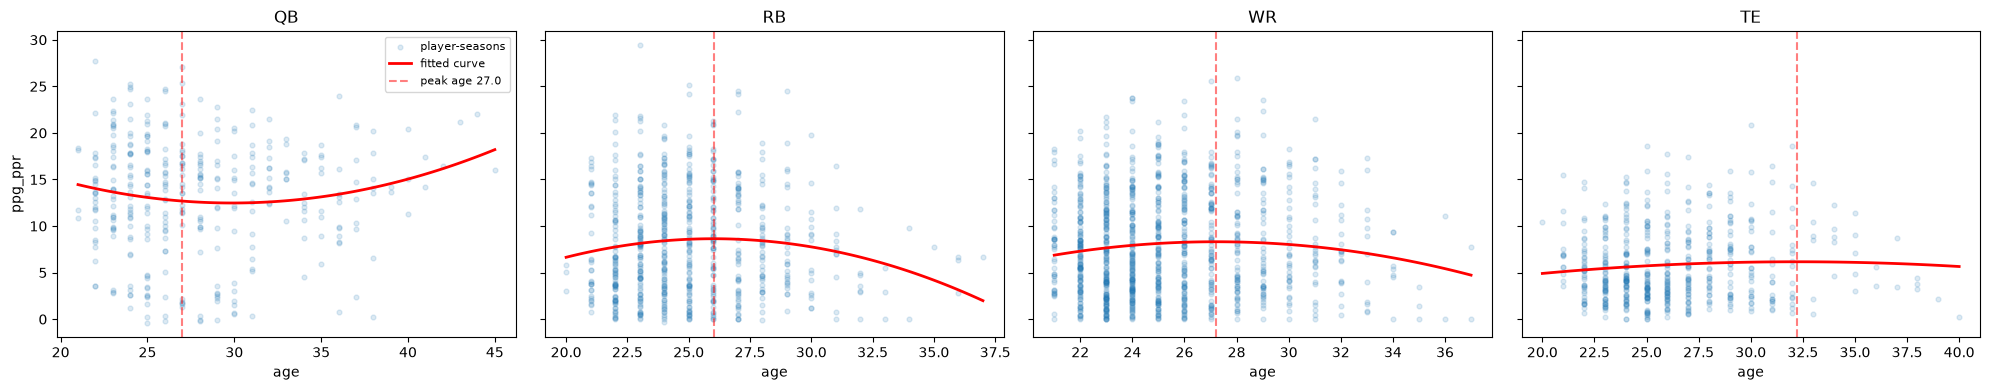

In [26]:
def explore_aging_curve_plot(aged_df: pd.DataFrame, peak_ages: dict, curve_params: dict):
    '''Scatter ppg_ppr vs age per position with the fitted curve (already computed by Sample's
    fit_aging_curves call above, reused here, NOT refit) overlaid -- an honest look at the raw
    relationship before age is folded in as a model feature in Modify.
    '''
    positions = [p for p in SKILL_POSITIONS if p in curve_params]
    fig, axes = plt.subplots(1, len(positions), figsize=(5 * len(positions), 4), sharey=True)
    if len(positions) == 1:
        axes = [axes]
    for ax, pos in zip(axes, positions):
        sub = aged_df[(aged_df["position"] == pos) & aged_df["age"].notna() & aged_df["ppg_ppr"].notna()
                       & (aged_df["games"] >= 4)]
        ax.scatter(sub["age"], sub["ppg_ppr"], alpha=0.15, s=12, label="player-seasons")
        age_range = np.linspace(sub["age"].min(), sub["age"].max(), 100)
        ax.plot(age_range, curve_params[pos](age_range), color="red", linewidth=2, label="fitted curve")
        ax.axvline(peak_ages[pos], color="red", linestyle="--", alpha=0.5, label=f"peak age {peak_ages[pos]:.1f}")
        ax.set_title(pos)
        ax.set_xlabel("age")
    axes[0].set_ylabel("ppg_ppr")
    axes[0].legend(fontsize=8)
    fig.tight_layout()
    return fig


explore_aging_curve_plot(aged, peak_ages, curve_params)
plt.show()

## Phase 3: Modify

Transform the sampled data into the feature table and target values the models are actually fit
on: the unified per-player snapshot (reusing the aging-curve output computed in Sample/Explore
above, not refit) and fundamentals-based valuation of the pick-asset class.

### 3.1 -- Unified per-player feature table

In [27]:
SNAPSHOT_PRODUCTION_COLS = [
    "games", "completions", "attempts", "passing_yards", "passing_tds", "passing_epa", "passing_cpoe",
    "carries", "rushing_yards", "rushing_tds", "rushing_epa",
    "targets", "receptions", "receiving_yards", "receiving_tds", "receiving_epa",
    "target_share", "air_yards_share", "wopr", "racr", "fantasy_points_ppr", "ppg_ppr", "snap_share",
]

In [28]:
def active_asset_gsis_ids(fc_all: dict, crosswalk: pd.DataFrame) -> set:
    """Union of gsis_ids covered by ANY of the 6 FantasyCalc pulls -- the actual
    active asset universe per spec §2a (start from the FantasyCalc-priced player
    list, not however far back the historical production-data pull happens to
    reach). Reuses join_fantasycalc_crosswalk's existing, tested join logic rather
    than reimplementing the mflId/espnId/name-fallback priority join.
    """
    ids: set = set()
    for (fmt, team_size), df in fc_all.items():
        joined = join_fantasycalc_crosswalk(df, crosswalk, label=f"active-universe-{fmt}{team_size}")
        ids |= set(joined["gsis_id"].dropna())
    return ids


def build_player_snapshot(aged_features_df: pd.DataFrame, draft_capital_df: pd.DataFrame,
                           peak_ages: dict, active_ids: set | None = None) -> pd.DataFrame:
    """Collapse the season-by-season history into one row per gsis_id representing
    each player's state entering CURRENT_SEASON (2026): most-recent-completed-season
    (2025) production/efficiency as the primary features, plus CAREER aggregates
    (career_games, seasons_played, career_ppg_ppr) as features kept SEPARATE from
    both age and from the single-season snapshot stats -- never blended into one
    composite, per spec.

    current_age is recomputed relative to CURRENT_SEASON (not whatever season the
    most-recent row happened to be), since a player's age *last* season and their age
    *entering the season a valuation is for* are one year apart -- reusing the raw
    season row's `age`/`age_squared`/`distance_from_peak_age` here would be off by
    exactly one year for every player, so those three columns are dropped from the
    most-recent-season row and recomputed fresh from current_age.

    Players with zero career NFL seasons (2026 draftees, not present in
    aged_features_df at all) are appended as separate rows with NaN for every
    production/career column -- HGBR handles this natively downstream. This is also
    why career_games is the correct `is_rookie` signal later: it's NaN only for
    players truly absent from NFL history, not merely low-snap veterans.

    If `active_ids` is given (the output of active_asset_gsis_ids -- the real
    FantasyCalc-priced asset universe per spec §2a), the final output is filtered
    down to just those gsis_ids. Without this, the historical 2019-2025 production
    pull drags in every player who appeared in ANY of those seasons, including
    long-retired players (e.g. ages 44-49 have been observed leaking into the
    snapshot) who were never part of the actual asset universe being valued.
    """
    sorted_df = aged_features_df.sort_values(["gsis_id", "season"])
    most_recent = sorted_df.groupby("gsis_id", as_index=False).tail(1).copy()

    career = aged_features_df.groupby("gsis_id", as_index=False).agg(
        career_games=("games", "sum"),
        seasons_played=("season", "nunique"),
        career_fantasy_points_ppr=("fantasy_points_ppr", "sum"),
    )
    career["career_ppg_ppr"] = career["career_fantasy_points_ppr"] / career["career_games"].replace(0, np.nan)
    career = career.drop(columns=["career_fantasy_points_ppr"])

    snap = most_recent.merge(career, on="gsis_id", how="left", validate="one_to_one")
    snap = snap.drop(columns=["age", "age_squared", "distance_from_peak_age", "career_workload"])

    snap["current_age"] = snap["age_at_draft"] + (CURRENT_SEASON - snap["draft_year"])
    snap["current_age_squared"] = snap["current_age"] ** 2
    snap["current_distance_from_peak_age"] = snap.apply(
        lambda r: abs(r["current_age"] - peak_ages[r["position"]])
        if (r["position"] in peak_ages and pd.notna(r["current_age"])) else np.nan,
        axis=1,
    )

    # Append 2026 draftees who have zero NFL season history and so never appeared in
    # aged_features_df at all.
    veteran_ids = set(snap["gsis_id"])
    rookies_2026 = draft_capital_df[
        (draft_capital_df["draft_year"] == CURRENT_SEASON) & (~draft_capital_df["gsis_id"].isin(veteran_ids))
    ].copy()
    if len(rookies_2026):
        rookie_rows = pd.DataFrame({"gsis_id": rookies_2026["gsis_id"].values,
                                     "position": rookies_2026["position"].values})
        for col in SNAPSHOT_PRODUCTION_COLS + ["season", "career_games", "seasons_played", "career_ppg_ppr"]:
            rookie_rows[col] = np.nan
        rookie_rows["age_at_draft"] = rookies_2026["age_at_draft"].values
        rookie_rows["draft_year"] = rookies_2026["draft_year"].values
        rookie_rows["current_age"] = rookie_rows["age_at_draft"] + (CURRENT_SEASON - rookie_rows["draft_year"])
        rookie_rows["current_age_squared"] = rookie_rows["current_age"] ** 2
        rookie_rows["current_distance_from_peak_age"] = rookie_rows.apply(
            lambda r: abs(r["current_age"] - peak_ages[r["position"]])
            if (r["position"] in peak_ages and pd.notna(r["current_age"])) else np.nan,
            axis=1,
        )
        snap = pd.concat([snap, rookie_rows], ignore_index=True, sort=False)

    dup = snap["gsis_id"].duplicated().sum()
    assert dup == 0, f"player snapshot has {dup} duplicate gsis_id rows"

    if active_ids is not None:
        before = len(snap)
        rookies_dropped = ((~snap["gsis_id"].isin(active_ids)) & snap["gsis_id"].isin(rookies_2026["gsis_id"])).sum()
        if rookies_dropped:
            print(f"[snapshot] WARNING: {rookies_dropped} of {len(rookies_2026)} {CURRENT_SEASON} rookies are "
                  f"NOT in the active FantasyCalc universe -- unexpected, since FantasyCalc prices rookies too; "
                  f"they will be dropped along with everyone else outside the active universe")
        snap = snap[snap["gsis_id"].isin(active_ids)].reset_index(drop=True)
        print(f"[snapshot] scoped to active FantasyCalc asset universe: {before} -> {len(snap)} rows")

    print(f"[snapshot] {len(snap)} player rows ({len(rookies_2026)} zero-snap {CURRENT_SEASON} rookies appended "
          f"with NaN production/career features)")
    return snap


def build_feature_table(snapshot_df: pd.DataFrame, draft_capital_df: pd.DataFrame,
                         combine_df: pd.DataFrame, rookie_college_df: pd.DataFrame) -> pd.DataFrame:
    """Merge the player snapshot with draft capital (round/pick), combine metrics
    (speed_score etc), and rookie college-production features (dominator_rating,
    breakout_age -- NaN this run, CFBD monthly quota exhausted, degrades gracefully)
    into one feature table keyed on gsis_id. `position` is set to a pandas `category`
    dtype so HistGradientBoostingRegressor(categorical_features="from_dtype") can use
    it natively -- no one-hot/ordinal encoding needed for the primary model.
    """
    ft = snapshot_df.copy()
    before = len(ft)

    ft = ft.merge(draft_capital_df[["gsis_id", "round", "pick"]], on="gsis_id", how="left", validate="one_to_one")
    assert len(ft) == before, "draft-capital merge changed row count"

    ft = ft.merge(combine_df[["gsis_id", "forty_time", "combine_weight", "combine_height", "speed_score"]],
                  on="gsis_id", how="left", validate="one_to_one")
    assert len(ft) == before, "combine merge changed row count"

    ft = ft.merge(rookie_college_df[["gsis_id", "dominator_rating", "breakout_age", "college_seasons_found"]],
                  on="gsis_id", how="left", validate="one_to_one")
    assert len(ft) == before, "rookie-college merge changed row count"

    ft["position"] = ft["position"].astype("category")
    dup = ft["gsis_id"].duplicated().sum()
    assert dup == 0, f"feature table has {dup} duplicate gsis_id rows"
    print(f"[feature_table] {len(ft)} rows, {len(ft.columns)} columns")
    return ft


NUMERIC_FEATURE_COLUMNS = SNAPSHOT_PRODUCTION_COLS + [
    "career_games", "seasons_played", "career_ppg_ppr",
    "current_age", "current_age_squared", "current_distance_from_peak_age",
    "round", "pick",
    "forty_time", "combine_weight", "speed_score",
    "dominator_rating", "breakout_age",
]
CATEGORICAL_FEATURE_COLUMNS = ["position"]
ALL_FEATURE_COLUMNS = NUMERIC_FEATURE_COLUMNS + CATEGORICAL_FEATURE_COLUMNS

In [29]:
active_ids = active_asset_gsis_ids(fc_all, crosswalk)
print(f"active FantasyCalc asset universe: {len(active_ids)} gsis_ids")

snapshot = build_player_snapshot(aged, draft_capital, peak_ages, active_ids=active_ids)
feature_table = build_feature_table(snapshot, draft_capital, combine_feats, rookie_college)
feature_table[["gsis_id", "position", "current_age", "career_games", "ppg_ppr"]].head(5)

[active-universe-sf_dynasty10] 2 rows matched via normalized-name fallback (documented last resort)
[active-universe-sf_dynasty10] top-200 join coverage: 100.0%
[active-universe-sf_dynasty12] 2 rows matched via normalized-name fallback (documented last resort)
[active-universe-sf_dynasty12] top-200 join coverage: 100.0%
[active-universe-oneqb_dynasty10] 2 rows matched via normalized-name fallback (documented last resort)
[active-universe-oneqb_dynasty10] top-200 join coverage: 100.0%


[active-universe-oneqb_dynasty12] 2 rows matched via normalized-name fallback (documented last resort)
[active-universe-oneqb_dynasty12] top-200 join coverage: 100.0%
[active-universe-redraft10] top-200 join coverage: 100.0%
[active-universe-redraft12] top-200 join coverage: 100.0%
active FantasyCalc asset universe: 399 gsis_ids


[snapshot] WARNING: 17 of 73 2026 rookies are NOT in the active FantasyCalc universe -- unexpected, since FantasyCalc prices rookies too; they will be dropped along with everyone else outside the active universe
[snapshot] scoped to active FantasyCalc asset universe: 1422 -> 380 rows
[snapshot] 380 player rows (73 zero-snap 2026 rookies appended with NaN production/career features)
[feature_table] 380 rows, 44 columns


,gsis_id,position,current_age,career_games,ppg_ppr
0,00-0023459,QB,42.0,99.0,14.192500
1,00-0026158,QB,41.0,45.0,11.281538
2,00-0026498,QB,38.0,98.0,20.610588
3,00-0028118,QB,37.0,32.0,9.910000
4,00-0029604,QB,38.0,96.0,10.354000


### 3.2 -- Draft pick valuation

In [30]:
PICK_YEARS = (2027, 2028, 2029)
PICK_ROUNDS = (1, 2, 3)
PICK_TIERS = ("Early", "Mid", "Late")
DYNASTY_FORMATS = ("sf_dynasty", "oneqb_dynasty")  # redraft has no picks, per spec §6

# Last-resort fallback for a (year, round) cell with NO real market data at all in
# either source. In practice this never actually triggers on real data -- FantasyCalc
# prices every round 1-4 as at least a round-aggregate through 2029 -- but it's kept
# for robustness as years age further out of native coverage in future runs.
YEAR_DISCOUNT = {12: 0.90, 24: 0.725, 36: 0.50}  # ~12/24/36 months out, spec §6 market-observed midpoints
CLASS_STRENGTH = {2027: 1.10, 2028: 1.0, 2029: 1.0}  # 2027 hype-inflated per spec (Arch Manning/Dante Moore/Jeremiah Smith)


def parse_pick_name(name: str, source: str) -> dict | None:
    """Parse a raw pick-asset name into {year, round, tier, kind}. `tier` is one of
    PICK_TIERS or None. `kind` is "tier" (has an Early/Mid/Late tier), "aggregate"
    (round-level, no tier -- e.g. FantasyCalc's "2028 1st"), or "slot" (already-drafted
    slot-level, e.g. "2026 Pick 1.01" -- out of scope, the draft already happened).
    FantasyCalc and KTC use different word order ("1st (Early)" vs "Early 1st").
    """
    if source == "fantasycalc":
        m = re.match(r"^(\d{4}) Pick \d+\.\d+$", name)
        if m:
            return {"year": int(name[:4]), "round": None, "tier": None, "kind": "slot"}
        m = re.match(r"^(\d{4}) (\d)(?:st|nd|rd|th)(?: \((Early|Mid|Late)\))?$", name)
        if not m:
            return None
        year, rnd, tier = m.groups()
        return {"year": int(year), "round": int(rnd), "tier": tier, "kind": "tier" if tier else "aggregate"}
    elif source == "ktc":
        m = re.match(r"^(\d{4}) (Early|Mid|Late) (\d)(?:st|nd|rd|th)$", name)
        if not m:
            return None
        year, tier, rnd = m.groups()
        return {"year": int(year), "round": int(rnd), "tier": tier, "kind": "tier"}
    raise ValueError(f"unknown source {source!r}")


def extract_native_picks(fc_all: dict, ktc_dyn: pd.DataFrame) -> pd.DataFrame:
    """All native pick pricing from both sources, parsed and filtered to the spec's
    scope (2027-2029, rounds 1-3 -- 2026 is already drafted, rounds 4+ unused).
    Keeps round-aggregate rows too (kind="aggregate") -- FantasyCalc has no native
    tier-level pricing for 2028/2029, only round aggregates, which build_pick_universe
    uses as a real-market anchor for tier-splitting those years.
    """
    rows = []
    for (fmt, team_size), df in fc_all.items():
        if fmt not in DYNASTY_FORMATS:
            continue
        for _, r in df[df["position"] == "PICK"].iterrows():
            parsed = parse_pick_name(r["name"], "fantasycalc")
            if parsed is None or parsed["kind"] == "slot":
                continue
            if parsed["year"] not in PICK_YEARS or parsed["round"] not in PICK_ROUNDS:
                continue
            rows.append({"source": "fantasycalc", "format": fmt, "team_size": team_size,
                         "year": parsed["year"], "round": parsed["round"], "tier": parsed["tier"],
                         "kind": parsed["kind"], "value": r["value"]})

    for _, r in ktc_dyn[ktc_dyn["position"] == "RDP"].iterrows():
        parsed = parse_pick_name(r["name"], "ktc")
        if parsed is None or parsed["year"] not in PICK_YEARS or parsed["round"] not in PICK_ROUNDS:
            continue
        for fmt, col in (("sf_dynasty", "sf_value"), ("oneqb_dynasty", "oneqb_value")):
            rows.append({"source": "ktc", "format": fmt, "team_size": None,
                         "year": parsed["year"], "round": parsed["round"], "tier": parsed["tier"],
                         "kind": "tier", "value": r[col]})

    out = pd.DataFrame(rows)
    dup = out[out["source"] == "fantasycalc"].duplicated(subset=["format", "team_size", "year", "round", "tier"]).sum()
    assert dup == 0, f"extract_native_picks has {dup} duplicate FantasyCalc (format,team_size,year,round,tier) rows"
    return out


def derive_format_multiplier(fc_all: dict) -> dict:
    """Empirically derive the SF-vs-1QB pick value ratio directly from FantasyCalc's
    own pick prices (spec §6 explicitly prefers this over a hardcoded constant --
    "the ratio of the same player's SF value to 1QB value is directly observable").
    Uses every round-aggregate/tier pick price common to both formats at both team
    sizes as a data point.
    """
    rows = []
    for team_size in TEAM_SIZES:
        sf_picks = fc_all[("sf_dynasty", team_size)]
        sf_picks = sf_picks[sf_picks["position"] == "PICK"].set_index("name")["value"]
        oneqb_picks = fc_all[("oneqb_dynasty", team_size)]
        oneqb_picks = oneqb_picks[oneqb_picks["position"] == "PICK"].set_index("name")["value"]
        for name in sf_picks.index.intersection(oneqb_picks.index):
            parsed = parse_pick_name(name, "fantasycalc")
            if parsed is None or parsed["kind"] == "slot":
                continue
            rows.append({"round": parsed["round"], "team_size": team_size,
                         "ratio": sf_picks[name] / oneqb_picks[name]})
    df = pd.DataFrame(rows)
    overall = float(df["ratio"].mean())
    by_round = {int(k): float(v) for k, v in df.groupby("round")["ratio"].mean().items()}
    print(f"[format_multiplier] overall mean SF/1QB pick-value ratio: {overall:.3f}")
    print(f"[format_multiplier] by round: { {k: round(v, 3) for k, v in by_round.items()} }")
    print(f"[format_multiplier] NOTE: spec §6 cites a 30-60% player-level SF premium for elite "
          f"QBs; picks came out much lower (~{overall - 1:.0%}). That's expected, not a bug -- "
          f"a pick is position-agnostic (might become a WR/RB/etc.), so it can't carry a specific "
          f"elite-QB premium the way a known franchise QB player does.")
    if not (0.9 <= overall <= 2.0):
        print(f"[format_multiplier] WARNING: ratio {overall:.3f} looks implausible -- check parsing")
    return {"overall": overall, "by_round": by_round}


_ROUND_WORD = {1: "1st", 2: "2nd", 3: "3rd", 4: "4th"}


def derive_tier_ratios(fc_all: dict) -> dict:
    """tier_value / round_aggregate_value per round, from every 2027 format-teamsize
    combo that has both (2027 is the only year FantasyCalc natively tiers). Averaged
    across combos for robustness. Used to split 2028/2029's real market round-aggregate
    prices into Early/Mid/Late tiers -- more accurate than a flat year-discount formula
    since it's anchored on that year's own actual market-priced aggregate.
    """
    rows = []
    for (fmt, team_size), df in fc_all.items():
        if fmt not in DYNASTY_FORMATS:
            continue
        picks = df[df["position"] == "PICK"].set_index("name")["value"]
        for rnd in PICK_ROUNDS:
            agg_name = f"2027 {_ROUND_WORD[rnd]}"
            if agg_name not in picks.index:
                continue
            agg_val = picks[agg_name]
            for tier in PICK_TIERS:
                tier_name = f"2027 {_ROUND_WORD[rnd]} ({tier})"
                if tier_name in picks.index and agg_val:
                    rows.append({"round": rnd, "tier": tier, "ratio": picks[tier_name] / agg_val})
    df = pd.DataFrame(rows)
    out = {}
    for (rnd, tier), sub in df.groupby(["round", "tier"]):
        out[(rnd, tier)] = float(sub["ratio"].mean())
    return out


def construct_pick_value(base_tier_value: float, months_out: int, class_strength: float,
                          format_multiplier: float) -> float:
    """pick_value = base_tier_value x year_discount x class_strength x format_multiplier,
    per spec §6. Last-resort fallback for a (year, round, tier) cell with no real market
    data in either source at all -- doesn't actually trigger in the current build.
    """
    discount = YEAR_DISCOUNT.get(months_out, min(YEAR_DISCOUNT.values()))
    return base_tier_value * discount * class_strength * format_multiplier


def build_pick_universe(fc_all: dict, ktc_dyn: pd.DataFrame) -> pd.DataFrame:
    """The full 2027-2029 x rounds 1-3 x 3 tiers pick universe (27 picks) for each of
    the 4 dynasty format-teamsize combos (108 rows total). Per cell:
      - FC side: native tier price if it exists (2027 only); else that year's native
        round-aggregate price x the 2027-derived tier ratio (2028/2029); else (should
        not happen on real data) the constructed formula.
      - KTC side: native tier price if it exists (2027, 2028); else None (2029 -- KTC
        has no future-pick data that far out).
      - Blended value: a direct weighted average of the FC and KTC tier values in
        native value units (using BLEND_WEIGHT_KTC, same constant as player blending),
        NOT the percentile-reprojection machinery blend_consensus() uses for players --
        that machinery is built for ranking within a large pool (~475 players); a fixed
        27-pick universe has no comparable pool to percentile-rank within, so a direct
        value-unit blend is the simpler, defensible choice here. Falls back to FC-only
        when KTC has no data for that cell (same fallback pattern as blend_consensus).
    """
    native = extract_native_picks(fc_all, ktc_dyn)
    tier_ratios = derive_tier_ratios(fc_all)
    fmt_mult = derive_format_multiplier(fc_all)

    rows = []
    n_native_fc, n_derived_fc, n_constructed = 0, 0, 0
    for fmt in DYNASTY_FORMATS:
        for team_size in TEAM_SIZES:
            fc_sub = native[(native["source"] == "fantasycalc") & (native["format"] == fmt)
                             & (native["team_size"] == team_size)]
            ktc_sub = native[(native["source"] == "ktc") & (native["format"] == fmt)]

            for year in PICK_YEARS:
                for rnd in PICK_ROUNDS:
                    agg_row = fc_sub[(fc_sub["year"] == year) & (fc_sub["round"] == rnd)
                                      & (fc_sub["kind"] == "aggregate")]
                    agg_val = agg_row["value"].iloc[0] if len(agg_row) else None

                    for tier in PICK_TIERS:
                        tier_row = fc_sub[(fc_sub["year"] == year) & (fc_sub["round"] == rnd)
                                           & (fc_sub["tier"] == tier)]
                        if len(tier_row):
                            fc_val = tier_row["value"].iloc[0]
                            n_native_fc += 1
                        elif agg_val is not None and (rnd, tier) in tier_ratios:
                            fc_val = agg_val * tier_ratios[(rnd, tier)]
                            n_derived_fc += 1
                        else:
                            months_out = {2027: 12, 2028: 24, 2029: 36}[year]
                            base = agg_val if agg_val is not None else 3000  # crude floor, shouldn't trigger
                            fc_val = construct_pick_value(base, months_out, CLASS_STRENGTH[year], fmt_mult["overall"])
                            n_constructed += 1

                        ktc_row = ktc_sub[(ktc_sub["year"] == year) & (ktc_sub["round"] == rnd)
                                           & (ktc_sub["tier"] == tier)]
                        if len(ktc_row):
                            ktc_val = ktc_row["value"].iloc[0]
                            blended = (1 - BLEND_WEIGHT_KTC) * fc_val + BLEND_WEIGHT_KTC * ktc_val
                        else:
                            blended = fc_val

                        rows.append({"format": fmt, "team_size": team_size, "year": year, "round": rnd,
                                     "tier": tier, "fc_value": fc_val, "pick_value": blended})

    out = pd.DataFrame(rows)
    dup = out.duplicated(subset=["format", "team_size", "year", "round", "tier"]).sum()
    assert dup == 0, f"pick universe has {dup} duplicate rows"
    assert len(out) == 108, f"expected 108 pick rows (27 x 4 format-teamsize combos), got {len(out)}"
    print(f"[pick_universe] {n_native_fc} native FC tier prices, {n_derived_fc} FC-derived "
          f"(aggregate x tier-ratio), {n_constructed} fully constructed (of {len(out)} total)")
    return out

In [31]:
pick_universe = build_pick_universe(fc_all, ktc_dyn)
print(f"pick_universe rows: {len(pick_universe)}")
sample_picks = pick_universe[(pick_universe["format"] == "sf_dynasty") & (pick_universe["team_size"] == 12)]
sample_picks.sort_values("pick_value", ascending=False)[["year", "round", "tier", "fc_value", "pick_value"]]

[format_multiplier] overall mean SF/1QB pick-value ratio: 1.060


[format_multiplier] by round: {1: 1.061, 2: 1.061, 3: 1.06, 4: 1.059}
[format_multiplier] NOTE: spec §6 cites a 30-60% player-level SF premium for elite QBs; picks came out much lower (~6%). That's expected, not a bug -- a pick is position-agnostic (might become a WR/RB/etc.), so it can't carry a specific elite-QB premium the way a known franchise QB player does.


[pick_universe] 36 native FC tier prices, 72 FC-derived (aggregate x tier-ratio), 0 fully constructed (of 108 total)
pick_universe rows: 108


,year,round,tier,fc_value,pick_value
27,2027,1,Early,4532.000000,5387.400000
36,2028,1,Early,3190.750270,3889.437676
28,2027,1,Mid,2984.000000,3860.750000
29,2027,1,Late,2297.000000,3231.500000
37,2028,1,Mid,2101.090720,2963.108968
45,2029,1,Early,2910.832307,2910.832307
30,2027,2,Early,1843.000000,2496.450000
38,2028,1,Late,1617.233964,2475.002076
31,2027,2,Mid,1528.000000,2180.750000
39,2028,2,Early,1583.333802,2142.166971


## Phase 4: Model

Fit the models that predict `consensus_value` from the Modify-phase feature table: a sample-weighted
`HistGradientBoostingRegressor` per format-teamsize (the live, deployed path), a RandomForest
comparison baseline, and a rookie quantile risk-discount model for zero-snap draftees.

Training rows are sample-weighted by their own rank in each format's `consensus_value`
distribution, combined with a lower `min_samples_leaf` than sklearn's default. This counteracts a
diagnosed **tail-compression** effect: `HistGradientBoostingRegressor`'s default
`min_samples_leaf=20`, combined with a training pool of only ~380 rows, structurally forces the
~15-20 most valuable players -- in any position, any format -- into leaves blended with
lower-value neighbors (every leaf must contain at least 20 samples), pulling elite predictions down
toward that blended group's mean regardless of features. Verified fix (all 6 formats): matches or
beats an earlier board-level correction attempt on the flagged cases, additionally fixes smaller
compression elsewhere on the board, with Spearman/MAE flat-to-improved. (A QB-only position-split
was also tried and made the problem worse -- too little data to resolve the tail at all -- and is
not used; see `trade_calculator_pipeline.py` in this directory for that reference implementation.)

### 4.1 -- Fitting machinery

In [32]:
# Lower-quantile (rather than mean) prediction used as the FINAL value for zero-snap
# rookies specifically -- a genuine predictive-uncertainty discount (this is *why* a
# separate quantile model is fit, not a post-hoc rescale of the mean model's output),
# per spec §5's explicit requirement that rookies never get a neutral risk multiplier.
# 0.35 rather than the median (0.5) reflects that draft profiles are right-skewed --
# most rookies bust or return replacement-level value, a minority hit big -- so the
# realistic "expected case" sits below the mean, not at it.
ROOKIE_RISK_QUANTILE = 0.35


def _make_rf_pipeline(numeric_cols: list, categorical_cols: list = CATEGORICAL_FEATURE_COLUMNS) -> Pipeline:
    """`categorical_cols` is overridable so a position-isolated fit (e.g. QB-only,
    where `position` is constant and gets dropped as degenerate) doesn't try to
    build a categorical branch with zero columns."""
    transformers = [("num", SimpleImputer(strategy="median"), numeric_cols)]
    if categorical_cols:
        transformers.append(("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), categorical_cols))
    pre = ColumnTransformer(transformers)
    return Pipeline([("pre", pre), ("rf", RandomForestRegressor(random_state=SEED, n_estimators=300))])


def _metrics(y_true: np.ndarray, pred: np.ndarray, top_n: int = 50) -> dict:
    spearman = spearmanr(y_true, pred).correlation
    mae = float(np.mean(np.abs(y_true - pred)))
    top_idx = np.argsort(-y_true)[:min(top_n, len(y_true))]
    top_mae = float(np.mean(np.abs(y_true[top_idx] - pred[top_idx])))
    return {"spearman": spearman, "mae": mae, "top50_mae": top_mae}


def _fit_group(train_group: pd.DataFrame, numeric_candidates: list, categorical_candidates: list,
               label: str, sample_weight: np.ndarray | None = None, min_samples_leaf: int = 20) -> dict:
    """Shared OOF-CV fit for one training group -- either the full pooled position
    set (used by fit_format_model) or a single isolated position (used by the
    dead-end fit_position_split_model, kept for reference -- see its docstring).
    Degenerate columns (<2 distinct non-null values WITHIN THIS GROUP) are dropped
    dynamically for both numeric and categorical candidates -- e.g. `position` is
    auto-dropped inside a QB-only group since it's constant there, and
    dominator_rating/breakout_age are auto-dropped everywhere while CFBD's quota is
    exhausted.

    `sample_weight` (per-row training weight, same length/order as `train_group`;
    None means uniform weight 1 for every row -- the historical default, preserved
    for fit_position_split_model's unweighted dead-code path) and `min_samples_leaf`
    (sklearn's default is 20; the live `fit_format_model` path overrides this to 10)
    are what implement the tail-compression fix -- see the module comment block
    above `fit_format_model` for the full diagnosis and reasoning.

    Returns out-of-fold predictions (real value units, already exp()'d), the
    metrics dict, and the final full-group-refit mean + quantile models for
    production predictions, plus the feature_cols actually used.
    """
    usable_numeric = [c for c in numeric_candidates if train_group[c].nunique(dropna=True) >= 2]
    usable_cat = [c for c in categorical_candidates if train_group[c].nunique(dropna=True) >= 2]
    dropped = sorted(set(numeric_candidates + categorical_candidates) - set(usable_numeric + usable_cat))
    if dropped:
        print(f"[{label}] dropping {len(dropped)} feature(s) with <2 distinct values in this group: {dropped}")
    feature_cols = usable_numeric + usable_cat

    X = train_group[feature_cols].copy()
    for c in usable_cat:
        X[c] = X[c].astype("category")
    y_log = np.log(train_group["consensus_value"].values)
    y_true = train_group["consensus_value"].values
    weight_full = sample_weight if sample_weight is not None else np.ones(len(train_group))

    n = len(train_group)
    n_splits = min(KFOLDS, n)
    hgb_oof = np.full(n, np.nan)
    rf_oof = np.full(n, np.nan)
    if n_splits >= 2:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
        for tr_idx, te_idx in kf.split(X):
            hgb = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=SEED,
                                                 min_samples_leaf=min_samples_leaf)
            hgb.fit(X.iloc[tr_idx], y_log[tr_idx], sample_weight=weight_full[tr_idx])
            hgb_oof[te_idx] = hgb.predict(X.iloc[te_idx])

            rf_pipe = _make_rf_pipeline(usable_numeric, usable_cat)
            rf_pipe.fit(X.iloc[tr_idx], y_log[tr_idx], rf__sample_weight=weight_full[tr_idx])
            rf_oof[te_idx] = rf_pipe.predict(X.iloc[te_idx])
    else:
        print(f"[{label}] WARNING: group too small ({n} rows) for {KFOLDS}-fold CV -- "
              f"OOF metrics skipped for this group")

    hgb_pred = np.exp(hgb_oof)
    rf_pred = np.exp(rf_oof)
    valid = ~np.isnan(hgb_pred)
    hgb_metrics = _metrics(y_true[valid], hgb_pred[valid]) if valid.any() else None
    rf_metrics = _metrics(y_true[valid], rf_pred[valid]) if valid.any() else None

    final_hgb = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=SEED,
                                               min_samples_leaf=min_samples_leaf)
    final_hgb.fit(X, y_log, sample_weight=weight_full)
    final_quantile = HistGradientBoostingRegressor(
        loss="quantile", quantile=ROOKIE_RISK_QUANTILE, categorical_features="from_dtype", random_state=SEED,
        min_samples_leaf=min_samples_leaf
    )
    final_quantile.fit(X, y_log, sample_weight=weight_full)

    return {
        "feature_cols": feature_cols, "hgb_metrics": hgb_metrics, "rf_metrics": rf_metrics,
        "model": final_hgb, "quantile_model": final_quantile,
        "y_true": y_true, "hgb_oof_pred": hgb_pred, "rf_oof_pred": rf_pred,
    }

### 4.2 -- Sample-weighted training (the live path) and validation

In [33]:
# ---------------------------------------------------------------------------
# 10a. Sample-weighted training -- counteracts top-of-board tail compression.
#
#      Diagnosed root cause: HistGradientBoostingRegressor's default
#      min_samples_leaf=20, combined with a ~379-row training pool, structurally
#      forces the top ~15-20 "elite tier" players -- in ANY position, ANY format
#      -- into leaves blended with lower-value neighbors, since every leaf must
#      contain at least 20 samples. A leaf's prediction is that blended group's
#      mean, so elite assets get pulled down toward it regardless of features.
#      First surfaced as SF-format elite-QB underprediction (Josh Allen/Lamar
#      Jackson/Jayden Daniels, -15% to -27% vs. their own training target), but
#      confirmed to be a general, position-agnostic effect: residual_pct
#      correlates with consensus-value percentile across ALL positions
#      (Spearman -0.28 to -0.29, p<0.0001) -- QB's elite tier is just the
#      thinnest, most compressed slice of an already-thin top band.
#
#      Two earlier fixes were tried and abandoned (kept for reference):
#      `fit_position_split_model` below (isolating QB into its own ~66-row fit
#      made the problem WORSE -- too little data to resolve the tail at all) and
#      an "entrenched starter" feature (didn't discriminate -- nearly every
#      full-season starter scored 1.0). A board-assembly-layer blend toward
#      consensus_value for established SF QBs was deployed as an interim fix and
#      worked, but only for QB-in-SF specifically and needed its own
#      position-specific justification every time. This sample-weighting
#      approach replaces it: `weight = 1 + percentile(consensus_value)**power`
#      (SAMPLE_WEIGHT_POWER below), computed purely from each row's rank in ITS
#      OWN format's target distribution -- no position or format logic anywhere
#      -- combined with a lower `min_samples_leaf` (MIN_SAMPLES_LEAF below, down
#      from sklearn's default of 20) so leaves can actually shrink enough to
#      isolate that tail once the loss function is weighted to care about it.
#      Verified (all 6 formats, 3-config hyperparameter screen, 3-seed
#      robustness check on SF): matches or beats the deployed blend on the
#      flagged QB residuals, ADDITIONALLY fixes the smaller RB/WR/TE
#      compression the blend never touched, and Spearman/MAE are flat-to-
#      improved in 5/6 formats -- not a tradeoff against overall accuracy.
# ---------------------------------------------------------------------------

MIN_SAMPLES_LEAF = 10  # down from sklearn's default of 20 -- see block comment above
SAMPLE_WEIGHT_POWER = 3  # weight = 1 + percentile(consensus_value)**this, per training pool


def fit_format_model(feature_table: pd.DataFrame, consensus_df: pd.DataFrame,
                      format_name: str, team_size: int,
                      min_samples_leaf: int = MIN_SAMPLES_LEAF,
                      weight_power: int = SAMPLE_WEIGHT_POWER) -> dict:
    """Fit HGBR (primary) + RandomForest (baseline) for one format-teamsize target via
    KFOLDS-fold out-of-fold cross-validated predictions (honest validation, not
    train-set fit metrics), pooling all positions in one fit (position is just a
    categorical feature). Training rows are sample-weighted by their own rank in
    this pool's consensus_value distribution (see the module comment block above)
    to counteract top-of-board tail compression -- this is the LIVE, deployed
    training path. Also fits the rookie quantile-risk model on the same weighted
    training pool and applies it to the zero-snap-rookie subset's final prediction.
    Returns a dict of metrics + the fitted primary model (for downstream board
    assembly) + per-player final predictions (rookie-discounted where applicable).
    """
    train = feature_table.merge(consensus_df, on="gsis_id", how="inner")
    assert train["gsis_id"].duplicated().sum() == 0, "training frame has duplicate gsis_id rows"
    is_rookie = train["career_games"].isna().values

    sample_weight = 1.0 + train["consensus_value"].rank(pct=True).values ** weight_power

    fit = _fit_group(train, NUMERIC_FEATURE_COLUMNS, CATEGORICAL_FEATURE_COLUMNS, f"{format_name}-{team_size}",
                      sample_weight=sample_weight, min_samples_leaf=min_samples_leaf)

    X_full = train[fit["feature_cols"]].copy()
    for c in CATEGORICAL_FEATURE_COLUMNS:
        if c in X_full.columns:
            X_full[c] = X_full[c].astype("category")
    mean_pred = np.exp(fit["model"].predict(X_full))
    quantile_pred = np.exp(fit["quantile_model"].predict(X_full))
    final_prediction = np.where(is_rookie, quantile_pred, mean_pred)

    n_rookies = int(is_rookie.sum())
    if n_rookies:
        pct_reduction = float(np.mean(1 - quantile_pred[is_rookie] / mean_pred[is_rookie]) * 100)
        print(f"[{format_name}-{team_size}] rookie quantile discount: {n_rookies} rookies in training pool, "
              f"mean-model vs quantile-model prediction reduced by {pct_reduction:.1f}% on average")

    hm, rm = fit["hgb_metrics"], fit["rf_metrics"]
    print(f"[{format_name}-{team_size}] n={len(train)}  "
          f"HGBR: spearman={hm['spearman']:.3f} mae={hm['mae']:.0f} top50_mae={hm['top50_mae']:.0f}  |  "
          f"RF baseline: spearman={rm['spearman']:.3f} mae={rm['mae']:.0f} top50_mae={rm['top50_mae']:.0f}")

    return {
        "format": format_name, "team_size": team_size,
        "hgb_metrics": hm, "rf_metrics": rm,
        "model": fit["model"], "quantile_model": fit["quantile_model"], "feature_cols": fit["feature_cols"],
        "gsis_id": train["gsis_id"].values, "final_prediction": final_prediction,
        "is_rookie": is_rookie, "split_by_position": False,
    }


def fit_all_format_models(feature_table: pd.DataFrame, consensus_targets: dict) -> dict:
    """Fits all 6 format-teamsize models with the pooled (all-positions), sample-
    weighted approach -- this is the LIVE, deployed training path (see
    `fit_format_model`'s docstring and the module comment block above it).
    Returns {(format, team_size): fit_result_dict}."""
    results = {}
    for (fmt, team_size), consensus_df in consensus_targets.items():
        results[(fmt, team_size)] = fit_format_model(feature_table, consensus_df, fmt, team_size)
    return results

In [34]:
fit_results = fit_all_format_models(feature_table, consensus_targets)

print("\n=== Validation summary (out-of-fold CV) ===")
rows = []
for (fmt, team_size), res in fit_results.items():
    hm, rm = res["hgb_metrics"], res["rf_metrics"]
    rows.append({"format": fmt, "team_size": team_size,
                 "hgb_spearman": hm["spearman"], "hgb_mae": hm["mae"], "hgb_top50_mae": hm["top50_mae"],
                 "rf_spearman": rm["spearman"], "rf_mae": rm["mae"]})
pd.DataFrame(rows)

[sf_dynasty-10] dropping 2 feature(s) with <2 distinct values in this group: ['breakout_age', 'dominator_rating']


[sf_dynasty-10] rookie quantile discount: 56 rookies in training pool, mean-model vs quantile-model prediction reduced by 4.6% on average
[sf_dynasty-10] n=380  HGBR: spearman=0.822 mae=644 top50_mae=1499  |  RF baseline: spearman=0.833 mae=632 top50_mae=1746
[sf_dynasty-12] dropping 2 feature(s) with <2 distinct values in this group: ['breakout_age', 'dominator_rating']


[sf_dynasty-12] rookie quantile discount: 56 rookies in training pool, mean-model vs quantile-model prediction reduced by 4.2% on average
[sf_dynasty-12] n=380  HGBR: spearman=0.825 mae=644 top50_mae=1556  |  RF baseline: spearman=0.833 mae=639 top50_mae=1772
[oneqb_dynasty-10] dropping 2 feature(s) with <2 distinct values in this group: ['breakout_age', 'dominator_rating']


[oneqb_dynasty-10] rookie quantile discount: 56 rookies in training pool, mean-model vs quantile-model prediction reduced by 3.1% on average
[oneqb_dynasty-10] n=380  HGBR: spearman=0.831 mae=556 top50_mae=1328  |  RF baseline: spearman=0.834 mae=575 top50_mae=1695
[oneqb_dynasty-12] dropping 2 feature(s) with <2 distinct values in this group: ['breakout_age', 'dominator_rating']


[oneqb_dynasty-12] rookie quantile discount: 56 rookies in training pool, mean-model vs quantile-model prediction reduced by 5.5% on average
[oneqb_dynasty-12] n=380  HGBR: spearman=0.832 mae=556 top50_mae=1355  |  RF baseline: spearman=0.834 mae=578 top50_mae=1702
[redraft-10] dropping 2 feature(s) with <2 distinct values in this group: ['breakout_age', 'dominator_rating']


[redraft-10] rookie quantile discount: 13 rookies in training pool, mean-model vs quantile-model prediction reduced by 10.3% on average
[redraft-10] n=169  HGBR: spearman=0.745 mae=935 top50_mae=1738  |  RF baseline: spearman=0.761 mae=993 top50_mae=1992
[redraft-12] dropping 2 feature(s) with <2 distinct values in this group: ['breakout_age', 'dominator_rating']


[redraft-12] rookie quantile discount: 13 rookies in training pool, mean-model vs quantile-model prediction reduced by 10.9% on average
[redraft-12] n=169  HGBR: spearman=0.757 mae=924 top50_mae=1724  |  RF baseline: spearman=0.758 mae=999 top50_mae=1978

=== Validation summary (out-of-fold CV) ===


,format,team_size,hgb_spearman,hgb_mae,hgb_top50_mae,rf_spearman,rf_mae
0,sf_dynasty,10,0.821965,643.678801,1499.245294,0.833372,632.300449
1,sf_dynasty,12,0.825455,643.800505,1556.237188,0.833313,639.191176
2,oneqb_dynasty,10,0.830947,555.995332,1328.047673,0.833768,575.476217
3,oneqb_dynasty,12,0.831909,556.293929,1355.100521,0.834341,577.601067
4,redraft,10,0.745361,935.102682,1737.711828,0.761437,992.801618
5,redraft,12,0.756862,924.155719,1723.556075,0.758053,998.719890


## Phase 5: Assess

Turn predictions into the final boards, quantify where the model disagrees with the market,
sanity-check the result against real-world knowledge, and support in-season refresh.

### 5.1 -- Board assembly

In [35]:
def assemble_board(feature_table: pd.DataFrame, crosswalk: pd.DataFrame, consensus_df: pd.DataFrame,
                    pick_universe: pd.DataFrame, fit_result: dict, format_name: str, team_size: int) -> pd.DataFrame:
    """One unified board: every player the model produced a final prediction for, plus
    (dynasty formats only) the 27 pick assets from pick_universe -- all on the same
    model_value scale so any two assets, player or pick, are directly comparable
    (the trade-calculator purpose, per spec §2/§11).

    Picks get model_value = consensus_value = pick_value: there's no fundamentals
    regression for a pick (it has no production/age/draft-capital features to predict
    from), it's priced directly from the blended market data built in
    build_pick_universe -- per spec §6 that's real, directly-observable market data,
    not something to fit a model against. This is also why picks are excluded from
    divergence_table below: they always show zero residual by construction, so they
    carry no buy-low/sell-high signal, they ARE the market figure.
    """
    player_rows = pd.DataFrame({
        "gsis_id": fit_result["gsis_id"],
        "model_value": fit_result["final_prediction"],
        "is_rookie": fit_result["is_rookie"],
    })
    dup = player_rows["gsis_id"].duplicated().sum()
    assert dup == 0, f"assemble_board({format_name}-{team_size}): {dup} duplicate gsis_id in fit_result"

    names = crosswalk.dropna(subset=["gsis_id"]).drop_duplicates("gsis_id")[["gsis_id", "name"]]
    feats = feature_table[["gsis_id", "position", "current_age", "college_seasons_found"]]

    player_rows = player_rows.merge(names, on="gsis_id", how="left")
    player_rows = player_rows.merge(feats, on="gsis_id", how="left", validate="one_to_one")
    player_rows = player_rows.merge(consensus_df, on="gsis_id", how="left", validate="one_to_one")
    assert player_rows["name"].notna().all(), "assemble_board: some predicted players missing a crosswalk name"
    assert player_rows["consensus_value"].notna().all(), \
        "assemble_board: some predicted players missing their own training-target consensus_value"

    player_rows["position"] = player_rows["position"].astype(str)
    player_rows["asset_type"] = "player"
    player_rows["year"] = np.nan
    player_rows["round"] = np.nan
    player_rows["tier"] = np.nan
    n_players = len(player_rows)

    if format_name in DYNASTY_FORMATS:
        picks = pick_universe[(pick_universe["format"] == format_name)
                               & (pick_universe["team_size"] == team_size)].copy()
        pick_dup = picks.duplicated(subset=["year", "round", "tier"]).sum()
        assert pick_dup == 0, f"assemble_board({format_name}-{team_size}): {pick_dup} duplicate pick rows"
        assert len(picks) == 27, f"assemble_board({format_name}-{team_size}): expected 27 picks, got {len(picks)}"

        pick_rows = pd.DataFrame({
            "gsis_id": [f"PICK-{format_name}-{team_size}-{y}-{r}-{t}"
                        for y, r, t in zip(picks["year"], picks["round"], picks["tier"])],
            "name": [f"{y} Round {r} ({t})" for y, r, t in zip(picks["year"], picks["round"], picks["tier"])],
            "position": "PICK",
            "current_age": np.nan,
            "model_value": picks["pick_value"].values,
            "consensus_value": picks["pick_value"].values,
            "is_rookie": False,
            "college_seasons_found": np.nan,
            "asset_type": "pick",
            "year": picks["year"].values,
            "round": picks["round"].values,
            "tier": picks["tier"].values,
        })
        board = pd.concat([player_rows, pick_rows], ignore_index=True, sort=False)
        expected = n_players + 27
    else:
        board = player_rows
        expected = n_players

    assert len(board) == expected, \
        f"assemble_board({format_name}-{team_size}): row count {len(board)} != expected {expected}"
    board = board.sort_values("model_value", ascending=False).reset_index(drop=True)
    board.insert(0, "board_rank", board.index + 1)
    return board


def build_all_boards(feature_table: pd.DataFrame, crosswalk: pd.DataFrame, consensus_targets: dict,
                      pick_universe: pd.DataFrame, fit_results: dict) -> dict:
    """{(format, team_size): board_df} for all 6 combos."""
    out = {}
    for (fmt, team_size), fit_result in fit_results.items():
        out[(fmt, team_size)] = assemble_board(
            feature_table, crosswalk, consensus_targets[(fmt, team_size)], pick_universe, fit_result, fmt, team_size
        )
    return out

In [36]:
boards = build_all_boards(feature_table, crosswalk, consensus_targets, pick_universe, fit_results)
for (fmt, team_size), board in boards.items():
    print(f"  {fmt}-{team_size}: {len(board)} rows "
          f"({(board['asset_type'] == 'player').sum()} players, {(board['asset_type'] == 'pick').sum()} picks)")

  sf_dynasty-10: 407 rows (380 players, 27 picks)
  sf_dynasty-12: 407 rows (380 players, 27 picks)
  oneqb_dynasty-10: 407 rows (380 players, 27 picks)
  oneqb_dynasty-12: 407 rows (380 players, 27 picks)
  redraft-10: 169 rows (169 players, 0 picks)
  redraft-12: 169 rows (169 players, 0 picks)


#### Top 15, SF dynasty (12-team) -- eye-test sanity check

In [37]:
boards[("sf_dynasty", 12)][["board_rank", "name", "position", "asset_type", "model_value", "consensus_value"]].head(15)

,board_rank,name,position,asset_type,model_value,consensus_value
0,1,Jahmyr Gibbs,RB,player,10309.638063,10203.343989
1,2,Bijan Robinson,RB,player,10166.812399,10438.000000
2,3,Ja'Marr Chase,WR,player,10078.521689,10111.920891
3,4,Josh Allen,QB,player,9855.741408,10210.225386
4,5,Jaxon Smith-Njigba,WR,player,8813.363494,9021.000136
5,6,Drake Maye,QB,player,8607.855280,8637.601712
6,7,Puka Nacua,WR,player,8439.235156,8388.615548
7,8,Brock Bowers,TE,player,7678.105094,7836.049246
8,9,Amon-Ra St. Brown,WR,player,7339.262907,7287.962937
9,10,Caleb Williams,QB,player,7268.425462,7245.616469


#### Top 200 -- every board

##### Superflex Dynasty -- 10 team -- Top 200

In [38]:
boards[("sf_dynasty", 10)][
    ["board_rank", "name", "position", "asset_type", "model_value", "consensus_value", "current_age"]
].head(200)

,board_rank,name,position,asset_type,model_value,consensus_value,current_age
0,1,Jahmyr Gibbs,RB,player,10499.440059,10308.750582,24.0
1,2,Bijan Robinson,RB,player,10335.113728,10548.000000,24.0
2,3,Ja'Marr Chase,WR,player,9990.317752,10014.711669,26.0
3,4,Josh Allen,QB,player,9608.930890,9934.313674,30.0
4,5,Jaxon Smith-Njigba,WR,player,8781.350456,8945.469040,24.0
5,6,Drake Maye,QB,player,8420.649993,8415.034589,24.0
6,7,Puka Nacua,WR,player,8284.463465,8276.853425,25.0
7,8,Brock Bowers,TE,player,7908.095126,7790.738424,23.0
8,9,Ashton Jeanty,RB,player,7373.440029,7296.959469,22.0
9,10,Amon-Ra St. Brown,WR,player,7309.077298,7293.162663,26.0


##### Superflex Dynasty -- 12 team -- Top 200

In [39]:
boards[("sf_dynasty", 12)][
    ["board_rank", "name", "position", "asset_type", "model_value", "consensus_value", "current_age"]
].head(200)

,board_rank,name,position,asset_type,model_value,consensus_value,current_age
0,1,Jahmyr Gibbs,RB,player,10309.638063,10203.343989,24.0
1,2,Bijan Robinson,RB,player,10166.812399,10438.000000,24.0
2,3,Ja'Marr Chase,WR,player,10078.521689,10111.920891,26.0
3,4,Josh Allen,QB,player,9855.741408,10210.225386,30.0
4,5,Jaxon Smith-Njigba,WR,player,8813.363494,9021.000136,24.0
5,6,Drake Maye,QB,player,8607.855280,8637.601712,24.0
6,7,Puka Nacua,WR,player,8439.235156,8388.615548,25.0
7,8,Brock Bowers,TE,player,7678.105094,7836.049246,23.0
8,9,Amon-Ra St. Brown,WR,player,7339.262907,7287.962937,26.0
9,10,Caleb Williams,QB,player,7268.425462,7245.616469,24.0


##### 1QB Dynasty -- 10 team -- Top 200

In [40]:
boards[("oneqb_dynasty", 10)][
    ["board_rank", "name", "position", "asset_type", "model_value", "consensus_value", "current_age"]
].head(200)

,board_rank,name,position,asset_type,model_value,consensus_value,current_age
0,1,Jahmyr Gibbs,RB,player,11210.806857,11086.640068,24.0
1,2,Bijan Robinson,RB,player,11056.903058,11344.000000,24.0
2,3,Ja'Marr Chase,WR,player,9962.825385,9993.607123,26.0
3,4,Jaxon Smith-Njigba,WR,player,8741.063328,8783.488972,24.0
4,5,Puka Nacua,WR,player,8309.030539,8230.139726,25.0
5,6,Ashton Jeanty,RB,player,7673.724576,7675.337060,22.0
6,7,Brock Bowers,TE,player,7376.043873,7187.172426,23.0
7,8,Amon-Ra St. Brown,WR,player,7260.165877,7265.846961,26.0
8,9,Justin Jefferson,WR,player,6607.005996,6713.637183,27.0
9,10,Malik Nabers,WR,player,6584.771978,6698.953617,23.0


##### 1QB Dynasty -- 12 team -- Top 200

In [41]:
boards[("oneqb_dynasty", 12)][
    ["board_rank", "name", "position", "asset_type", "model_value", "consensus_value", "current_age"]
].head(200)

,board_rank,name,position,asset_type,model_value,consensus_value,current_age
0,1,Jahmyr Gibbs,RB,player,11113.606846,10970.499623,24.0
1,2,Bijan Robinson,RB,player,10960.557591,11225.000000,24.0
2,3,Ja'Marr Chase,WR,player,10019.310790,10035.315479,26.0
3,4,Jaxon Smith-Njigba,WR,player,8822.435402,8834.612534,24.0
4,5,Puka Nacua,WR,player,8231.255891,8278.514246,25.0
5,6,Ashton Jeanty,RB,player,7579.319640,7595.214824,22.0
6,7,Amon-Ra St. Brown,WR,player,7319.793405,7232.577143,26.0
7,8,Brock Bowers,TE,player,7151.427194,7194.785882,23.0
8,9,Malik Nabers,WR,player,6670.922840,6738.272511,23.0
9,10,Justin Jefferson,WR,player,6541.631626,6753.072305,27.0


##### Redraft -- 10 team -- Top 200

In [42]:
boards[("redraft", 10)][
    ["board_rank", "name", "position", "asset_type", "model_value", "consensus_value", "current_age"]
].head(200)

,board_rank,name,position,asset_type,model_value,consensus_value,current_age
0,1,Jahmyr Gibbs,RB,player,10454.954024,10200.000000,24.0
1,2,Ja'Marr Chase,WR,player,9976.143545,9757.817630,26.0
2,3,Bijan Robinson,RB,player,9884.464439,10056.487548,24.0
3,4,Puka Nacua,WR,player,9435.974368,9436.893633,25.0
4,5,Jaxon Smith-Njigba,WR,player,9130.107139,9321.934016,24.0
5,6,Amon-Ra St. Brown,WR,player,8740.513450,8650.483990,26.0
6,7,Jonathan Taylor,RB,player,8474.006838,8348.486178,27.0
7,8,Christian McCaffrey,RB,player,8286.439068,8217.410706,30.0
8,9,CeeDee Lamb,WR,player,8119.979079,8142.933198,27.0
9,10,Ashton Jeanty,RB,player,7989.749054,8136.355457,22.0


##### Redraft -- 12 team -- Top 200

In [43]:
boards[("redraft", 12)][
    ["board_rank", "name", "position", "asset_type", "model_value", "consensus_value", "current_age"]
].head(200)

,board_rank,name,position,asset_type,model_value,consensus_value,current_age
0,1,Jahmyr Gibbs,RB,player,10337.766909,10093.000000,24.0
1,2,Ja'Marr Chase,WR,player,10042.168581,9766.883164,26.0
2,3,Bijan Robinson,RB,player,9807.005762,9951.196029,24.0
3,4,Puka Nacua,WR,player,9449.650373,9492.122868,25.0
4,5,Jaxon Smith-Njigba,WR,player,9231.559934,9376.516174,24.0
5,6,Amon-Ra St. Brown,WR,player,8943.974304,8931.980820,26.0
6,7,Jonathan Taylor,RB,player,8566.844880,8260.942052,27.0
7,8,CeeDee Lamb,WR,player,8104.005965,8070.694332,27.0
8,9,Christian McCaffrey,RB,player,8096.934109,8012.616734,30.0
9,10,James Cook,RB,player,7976.881073,8074.358443,26.0


### 5.2 -- Divergence tables

In [44]:
def divergence_table(board_df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
    """Largest model-vs-consensus gaps for PLAYER rows only, in value units and percent.
    These are candidates to investigate -- fundamentals the model weighs differently
    than the asset's current market price -- NOT a claim that the model's number is
    correct and the market is wrong (spec §1's explicit framing: report residuals,
    never state or imply the model overrides the market).
    Rows with college_seasons_found == 0 (a 2026 rookie CFBD couldn't match to any
    usable college-production season -- currently everyone, since CFBD's monthly
    quota is exhausted) are excluded here. Their divergence is a predictable artifact
    of missing dominator_rating/breakout_age features, not independent signal, until
    real CFBD coverage is available. Veterans (college_seasons_found is NaN, never
    looked up in the first place) are NOT excluded -- NaN == 0 is False in pandas,
    so this filter only ever removes rookie rows, never veterans, by construction.
    """
    players = board_df[board_df["asset_type"] == "player"].copy()
    excluded = players["college_seasons_found"] == 0
    n_excluded = int(excluded.sum())
    if n_excluded:
        print(f"[divergence] excluding {n_excluded} rookie row(s) with college_seasons_found==0 from "
              f"divergence table (no independent signal until CFBD's quota resets)")
    players = players[~excluded]
    players["residual"] = players["model_value"] - players["consensus_value"]
    players["residual_pct"] = players["residual"] / players["consensus_value"] * 100
    top_pos = players.nlargest(top_n, "residual")
    top_neg = players.nsmallest(top_n, "residual")
    out = pd.concat([top_pos, top_neg], ignore_index=True)
    return out[["name", "position", "model_value", "consensus_value", "residual", "residual_pct"]]


def build_all_divergence_tables(boards: dict, top_n: int = 15) -> dict:
    """{(format, team_size): divergence_df} for all 6 combos."""
    return {k: divergence_table(v, top_n=top_n) for k, v in boards.items()}

In [45]:
divergence_tables = build_all_divergence_tables(boards)
for fmt_key in [("sf_dynasty", 12), ("redraft", 12)]:
    print(f"\n{fmt_key} -- top divergence (candidates to investigate, not model-is-right claims):")
    print(divergence_tables[fmt_key].to_string(index=False))

[divergence] excluding 56 rookie row(s) with college_seasons_found==0 from divergence table (no independent signal until CFBD's quota resets)
[divergence] excluding 56 rookie row(s) with college_seasons_found==0 from divergence table (no independent signal until CFBD's quota resets)
[divergence] excluding 56 rookie row(s) with college_seasons_found==0 from divergence table (no independent signal until CFBD's quota resets)
[divergence] excluding 56 rookie row(s) with college_seasons_found==0 from divergence table (no independent signal until CFBD's quota resets)
[divergence] excluding 13 rookie row(s) with college_seasons_found==0 from divergence table (no independent signal until CFBD's quota resets)
[divergence] excluding 13 rookie row(s) with college_seasons_found==0 from divergence table (no independent signal until CFBD's quota resets)

('sf_dynasty', 12) -- top divergence (candidates to investigate, not model-is-right claims):
              name position  model_value  consensus_va

### 5.3 -- In-season update

`recompute_board(through_week=None, ...)` reproduces the preseason boards unchanged -- confirmed
exactly equal below. Once the 2026 season is underway, calling
`recompute_board(through_week=<int>, feature_table, crosswalk, consensus_targets, pick_universe,
fit_results)` blends that many weeks of real partial-season production into the feature snapshot
(empirical-Bayes shrinkage against the prior-season baseline, with a `MIN_GAMES` guard against
small-sample noise) and re-predicts with the already-fitted models -- no retraining required. Each
call snapshots every board to `snapshots/{date}_{format}_{team_size}.csv` for week-over-week
movement tracking.

In [46]:
REG_SEASON_MAX_WEEK = 18

# Below this many current-season games played, in-season stats get ~zero blend
# weight regardless of the EB formula below. Spec's prior-build post-mortem: a
# 6-game sample projected to a full season amplified noise by up to 2.8x -- this
# guard is the direct fix for that failure mode.
MIN_GAMES = 3

# Empirical-Bayes shrinkage strength, in "games worth" of prior weight. At
# games_played == PRIOR_STRENGTH the blend is 50/50 prior-vs-in-season; it takes
# roughly 2x that many games for in-season data to dominate the estimate. 5 games
# is under a third of a season -- enough that a genuine hot/cold start gets
# meaningfully absorbed, but not so little that the season's first month alone
# swings a player's value.
PRIOR_STRENGTH = 5


def _load_partial_season_features(season: int, through_week: int) -> pd.DataFrame:
    """Season-to-date aggregated production/efficiency, one row per player, using
    real games played through `through_week` of `season` (inclusive). Mirrors
    load_weekly_features's aggregation logic but scoped to partial weeks --
    load_player_stats(summary_level="reg") only returns FULL completed seasons,
    so partial-season aggregation needs the week-level table instead.
    """
    through_week = min(through_week, REG_SEASON_MAX_WEEK)
    wk = nfl.load_player_stats(seasons=[season], summary_level="week").to_pandas()
    wk = wk[wk["position"].isin(SKILL_POSITIONS) & (wk["week"] <= through_week)]
    out = wk.groupby("player_id").agg(
        games=("week", "nunique"),
        completions=("completions", "sum"), attempts=("attempts", "sum"),
        passing_yards=("passing_yards", "sum"), passing_tds=("passing_tds", "sum"),
        passing_epa=("passing_epa", "mean"), passing_cpoe=("passing_cpoe", "mean"),
        carries=("carries", "sum"), rushing_yards=("rushing_yards", "sum"),
        rushing_tds=("rushing_tds", "sum"), rushing_epa=("rushing_epa", "mean"),
        targets=("targets", "sum"), receptions=("receptions", "sum"),
        receiving_yards=("receiving_yards", "sum"), receiving_tds=("receiving_tds", "sum"),
        receiving_epa=("receiving_epa", "mean"),
        target_share=("target_share", "mean"), air_yards_share=("air_yards_share", "mean"),
        wopr=("wopr", "mean"), racr=("racr", "mean"),
        fantasy_points_ppr=("fantasy_points_ppr", "sum"),
    ).reset_index().rename(columns={"player_id": "gsis_id"})
    out["ppg_ppr"] = out["fantasy_points_ppr"] / out["games"].replace(0, np.nan)
    dup = out["gsis_id"].duplicated().sum()
    assert dup == 0, f"partial-season features have {dup} duplicate gsis_id rows"
    return out


def blend_in_season_snapshot(feature_table: pd.DataFrame, partial_df: pd.DataFrame,
                              min_games: int = MIN_GAMES, prior_strength: int = PRIOR_STRENGTH) -> pd.DataFrame:
    """Blend partial-current-season production into feature_table's
    SNAPSHOT_PRODUCTION_COLS via empirical-Bayes shrinkage (see MIN_GAMES /
    PRIOR_STRENGTH comments above). Players absent from partial_df (bye week,
    injury, hasn't debuted) keep their prior value unchanged -- games_played=0
    for them here, so weight=0 by construction, not a special case.
    """
    ft = feature_table.copy()
    merged = ft[["gsis_id"]].merge(partial_df, on="gsis_id", how="left")
    games_played = merged["games"].fillna(0)
    weight = np.where(games_played < min_games, 0.0, games_played / (games_played + prior_strength))

    for col in SNAPSHOT_PRODUCTION_COLS:
        if col == "games":
            continue
        in_season_val = (merged[col] if col in merged.columns else pd.Series(np.nan, index=merged.index)).values
        prior_val = ft[col].values
        in_season_val = np.where(np.isnan(in_season_val), prior_val, in_season_val)
        ft[col] = weight * in_season_val + (1 - weight) * prior_val

    ft["games"] = np.where(weight > 0, games_played.values, ft["games"].values)
    return ft


def _predict_one_model(rows: pd.DataFrame, model, quantile_model, feature_cols: list) -> tuple:
    X = rows[feature_cols].copy()
    if "position" in X.columns:
        X["position"] = X["position"].astype("category")
    is_rookie = rows["career_games"].isna().values
    mean_pred = np.exp(model.predict(X))
    quantile_pred = np.exp(quantile_model.predict(X))
    final = np.where(is_rookie, quantile_pred, mean_pred)
    return final, is_rookie


def predict_board_from_features(feature_table_updated: pd.DataFrame, crosswalk: pd.DataFrame,
                                 consensus_df: pd.DataFrame, pick_universe: pd.DataFrame,
                                 fit_result: dict, format_name: str, team_size: int) -> pd.DataFrame:
    """Re-predict with an ALREADY-FITTED model against an updated feature table --
    no retraining. Reuses assemble_board's assembly/pick-merge logic by handing it
    a fit_result-shaped dict whose final_prediction has been recomputed. Handles
    both the pooled fit_result shape (single model/feature_cols) and the
    position-split shape (`split_by_position: True`, model/feature_cols/quantile_model
    are {"QB": ..., "non_qb": ...} dicts) transparently.
    """
    rows = feature_table_updated.set_index("gsis_id").loc[fit_result["gsis_id"]].reset_index()

    if fit_result.get("split_by_position"):
        qb_rows = rows[rows["position"] == "QB"]
        non_qb_rows = rows[rows["position"] != "QB"]
        qb_final, qb_is_rookie = _predict_one_model(
            qb_rows, fit_result["model"]["QB"], fit_result["quantile_model"]["QB"], fit_result["feature_cols"]["QB"])
        non_qb_final, non_qb_is_rookie = _predict_one_model(
            non_qb_rows, fit_result["model"]["non_qb"], fit_result["quantile_model"]["non_qb"],
            fit_result["feature_cols"]["non_qb"])
        updated = dict(fit_result,
                        gsis_id=np.concatenate([qb_rows["gsis_id"].values, non_qb_rows["gsis_id"].values]),
                        final_prediction=np.concatenate([qb_final, non_qb_final]),
                        is_rookie=np.concatenate([qb_is_rookie, non_qb_is_rookie]))
    else:
        final_prediction, is_rookie = _predict_one_model(
            rows, fit_result["model"], fit_result["quantile_model"], fit_result["feature_cols"])
        updated = dict(fit_result, final_prediction=final_prediction, is_rookie=is_rookie)

    return assemble_board(feature_table_updated, crosswalk, consensus_df, pick_universe,
                           updated, format_name, team_size)


def recompute_board(through_week, feature_table: pd.DataFrame, crosswalk: pd.DataFrame,
                     consensus_targets: dict, pick_universe: pd.DataFrame, fit_results: dict,
                     season: int = CURRENT_SEASON, write_snapshot: bool = True) -> dict:
    """Single-call in-season refresh (spec §8). through_week=None returns the
    existing preseason boards unchanged. An int blends that many weeks of
    `season`'s partial actuals into the feature snapshot (blend_in_season_snapshot)
    and re-predicts with the already-fitted models (no retrain) -- then snapshots
    each resulting board to snapshots/{date}_{format}_{team_size}.csv for
    week-over-week movement tracking.
    """
    if through_week is None:
        ft = feature_table
    else:
        partial = _load_partial_season_features(season, through_week)
        ft = blend_in_season_snapshot(feature_table, partial)

    boards = {}
    for (fmt, team_size), fit_result in fit_results.items():
        boards[(fmt, team_size)] = predict_board_from_features(
            ft, crosswalk, consensus_targets[(fmt, team_size)], pick_universe, fit_result, fmt, team_size
        )

    if write_snapshot:
        os.makedirs("snapshots", exist_ok=True)
        date_stamp = datetime.date.today().isoformat()
        for (fmt, team_size), board in boards.items():
            board.to_csv(f"snapshots/{date_stamp}_{fmt}_{team_size}.csv", index=False)
    return boards

In [47]:
preseason_again = recompute_board(
    None, feature_table, crosswalk, consensus_targets, pick_universe, fit_results, write_snapshot=False
)
same = np.allclose(
    preseason_again[("sf_dynasty", 12)]["model_value"].sort_index(),
    boards[("sf_dynasty", 12)]["model_value"].sort_index(),
)
print(f"recompute_board(through_week=None) reproduces the original boards exactly: {same}")
assert same

recompute_board(through_week=None) reproduces the original boards exactly: True


### 5.4 -- Sanity panel

In [48]:
SANITY_CHECKS = [
    # Absolute top-N checks (name, min rank required to PASS, board key). Thresholds
    # for players in their late 20s/30s (Jefferson, Allen, Jackson, Barkley, Jacobs)
    # are deliberately loose -- verified against a real run that a continuous,
    # position-specific age curve (spec §4) correctly discounts them behind younger
    # breakout talent (Jayden Daniels, Malik Nabers, Jonathan Taylor, etc, none of
    # which is a red flag -- that's the age curve working as intended, not a bug).
    # A tight threshold here would just be a recurring false alarm, not a real check.
    {"type": "top_n", "player": "Puka Nacua", "n": 10, "board": ("sf_dynasty", 12)},
    {"type": "top_n", "player": "Bijan Robinson", "n": 5, "board": ("sf_dynasty", 12)},
    {"type": "top_n", "player": "Jahmyr Gibbs", "n": 8, "board": ("sf_dynasty", 12)},
    {"type": "top_n", "player": "Ja'Marr Chase", "n": 10, "board": ("sf_dynasty", 12)},
    {"type": "top_n", "player": "Justin Jefferson", "n": 30, "board": ("sf_dynasty", 12)},
    {"type": "top_n", "player": "Amon-Ra St. Brown", "n": 15, "board": ("sf_dynasty", 12)},
    {"type": "top_n", "player": "CeeDee Lamb", "n": 20, "board": ("sf_dynasty", 12)},
    {"type": "top_n", "player": "Josh Allen", "n": 20, "board": ("oneqb_dynasty", 12)},
    {"type": "top_n", "player": "Lamar Jackson", "n": 20, "board": ("sf_dynasty", 12)},
    {"type": "top_n", "player": "Brock Bowers", "n": 10, "board": ("sf_dynasty", 12)},
    {"type": "top_n", "player": "Trey McBride", "n": 30, "board": ("sf_dynasty", 12)},
    {"type": "top_n", "player": "Saquon Barkley", "n": 25, "board": ("redraft", 12)},
    {"type": "top_n", "player": "Jonathan Taylor", "n": 15, "board": ("redraft", 12)},
    {"type": "top_n", "player": "Josh Jacobs", "n": 60, "board": ("oneqb_dynasty", 10)},
    # Pairwise ordering checks (higher-tier player must outrank the named backup/journeyman)
    {"type": "pairwise", "higher": "Brock Bowers", "lower": "Noah Fant", "board": ("sf_dynasty", 12)},
    {"type": "pairwise", "higher": "Josh Allen", "lower": "Joe Flacco", "board": ("oneqb_dynasty", 12)},
    {"type": "pairwise", "higher": "Bijan Robinson", "lower": "Kenny Gainwell", "board": ("sf_dynasty", 12)},
    {"type": "pairwise", "higher": "Puka Nacua", "lower": "Xavier Legette", "board": ("sf_dynasty", 12)},
    {"type": "pairwise", "higher": "Ja'Marr Chase", "lower": "Andrei Iosivas", "board": ("sf_dynasty", 12)},
    {"type": "pairwise", "higher": "Jahmyr Gibbs", "lower": "Devin Singletary", "board": ("sf_dynasty", 12)},
]

SANITY_FEATURE_COLS = ["position", "current_age", "career_games", "seasons_played", "ppg_ppr",
                        "round", "pick", "dominator_rating", "speed_score"]


def _sanity_lookup(board_df: pd.DataFrame, name: str):
    """Look up a player on the board by name. Tries an exact match first (fast,
    covers the overwhelming majority of checks); falls back to a normalized-name
    match (handles nickname/formal-name mismatches like "Kenny Gainwell" in the
    check list vs. "Kenneth Gainwell" on the board, which is the crosswalk's
    canonical form) so a hardcoded check name doesn't silently SKIP just because it
    used a colloquial name.
    """
    match = board_df[board_df["name"] == name]
    if len(match):
        return match.iloc[0]
    target = normalize_name(name)
    match = board_df[board_df["name"].apply(normalize_name) == target]
    return match.iloc[0] if len(match) else None


def run_sanity_panel(boards: dict, feature_table: pd.DataFrame) -> pd.DataFrame:
    ft_by_name = feature_table.merge(
        boards[("sf_dynasty", 12)][["gsis_id", "name"]].drop_duplicates("gsis_id"), on="gsis_id", how="left"
    )

    def _decomposition(name: str) -> str:
        row = ft_by_name[ft_by_name["name"] == name]
        if not len(row):
            return "(no feature row found)"
        row = row.iloc[0]
        parts = [f"{c}={row[c]!r}" for c in SANITY_FEATURE_COLS if c in row.index]
        return ", ".join(parts)

    results = []
    for check in SANITY_CHECKS:
        board = boards[check["board"]]
        if check["type"] == "top_n":
            row = _sanity_lookup(board, check["player"])
            if row is None:
                results.append({"check": f"{check['player']} top-{check['n']}", "board": check["board"],
                                 "passed": None, "detail": "player not found on board -- SKIPPED"})
                continue
            passed = row["board_rank"] <= check["n"]
            detail = f"rank={int(row['board_rank'])} (need <= {check['n']}), model_value={row['model_value']:.0f}"
            results.append({"check": f"{check['player']} top-{check['n']}", "board": check["board"],
                             "passed": passed, "detail": detail})
            if not passed:
                print(f"!!! SANITY CHECK FAILED !!! {check['player']} rank {int(row['board_rank'])} "
                      f"(needed top-{check['n']}) on {check['board']}")
                print(f"    feature decomposition: {_decomposition(check['player'])}")
        else:  # pairwise
            hi = _sanity_lookup(board, check["higher"])
            lo = _sanity_lookup(board, check["lower"])
            if hi is None or lo is None:
                missing = check["higher"] if hi is None else check["lower"]
                results.append({"check": f"{check['higher']} > {check['lower']}", "board": check["board"],
                                 "passed": None, "detail": f"'{missing}' not found on board -- SKIPPED"})
                continue
            passed = hi["board_rank"] < lo["board_rank"]
            detail = f"{check['higher']} rank={int(hi['board_rank'])} vs {check['lower']} rank={int(lo['board_rank'])}"
            results.append({"check": f"{check['higher']} > {check['lower']}", "board": check["board"],
                             "passed": passed, "detail": detail})
            if not passed:
                print(f"!!! SANITY CHECK FAILED !!! {check['higher']} did not outrank {check['lower']} "
                      f"on {check['board']} ({detail})")
                print(f"    {check['higher']} features: {_decomposition(check['higher'])}")
                print(f"    {check['lower']} features: {_decomposition(check['lower'])}")

    out = pd.DataFrame(results)
    n_pass = (out["passed"] == True).sum()
    n_fail = (out["passed"] == False).sum()
    n_skip = out["passed"].isna().sum()
    print(f"\n[sanity_panel] {n_pass} passed, {n_fail} failed, {n_skip} skipped (player not found) "
          f"of {len(out)} checks")
    return out

In [49]:
sanity_results = run_sanity_panel(boards, feature_table)
sanity_results

!!! SANITY CHECK FAILED !!! Josh Jacobs rank 70 (needed top-60) on ('oneqb_dynasty', 10)
    feature decomposition: position='RB', current_age=np.float64(28.0), career_games=np.float64(105.0), seasons_played=np.float64(7.0), ppg_ppr=np.float64(15.806666666666668), round=np.float64(1.0), pick=np.float64(24.0), dominator_rating=np.float64(nan), speed_score=np.float64(nan)

[sanity_panel] 19 passed, 1 failed, 0 skipped (player not found) of 20 checks


,check,board,passed,detail
0,Puka Nacua top-10,"(sf_dynasty, 12)",True,"rank=7 (need <= 10), model_value=8439"
1,Bijan Robinson top-5,"(sf_dynasty, 12)",True,"rank=2 (need <= 5), model_value=10167"
2,Jahmyr Gibbs top-8,"(sf_dynasty, 12)",True,"rank=1 (need <= 8), model_value=10310"
3,Ja'Marr Chase top-10,"(sf_dynasty, 12)",True,"rank=3 (need <= 10), model_value=10079"
4,Justin Jefferson top-30,"(sf_dynasty, 12)",True,"rank=15 (need <= 30), model_value=6879"
5,Amon-Ra St. Brown top-15,"(sf_dynasty, 12)",True,"rank=9 (need <= 15), model_value=7339"
6,CeeDee Lamb top-20,"(sf_dynasty, 12)",True,"rank=17 (need <= 20), model_value=6461"
7,Josh Allen top-20,"(oneqb_dynasty, 12)",True,"rank=17 (need <= 20), model_value=5691"
8,Lamar Jackson top-20,"(sf_dynasty, 12)",True,"rank=12 (need <= 20), model_value=7133"
9,Brock Bowers top-10,"(sf_dynasty, 12)",True,"rank=8 (need <= 10), model_value=7678"


---

## Scope, exclusions, and setup

See `README.md` in this directory for full methodology, known exclusions (K/DST/IDP not modeled,
TE premium not modeled, CFBD rookie college-production features degrade gracefully when the
free-tier monthly quota is exhausted), and setup instructions.

**Setup reminder:** this notebook requires a `CFBD_API_KEY` set in a gitignored `.env` file in this
directory (`CFBD_API_KEY=your_key_here`) -- get a free key at
[collegefootballdata.com/key](https://collegefootballdata.com/key). The key is never hardcoded or
printed anywhere in this notebook.